## 1.导入需要的库

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

OUTPUT_DIR = Path("../figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

WindowsPath('../figures')

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns

excel_path = Path(r"outputs/results.xlsx")

def read_metric_sheet(sheet_name_or_index, metric_name):
    df = pd.read_excel(excel_path, sheet_name=sheet_name_or_index)

    df.columns = [str(c).strip() for c in df.columns]
    df = df.iloc[:,0:8]
   
    time_col = "时间" if "时间" in df.columns else df.columns[0]
    long_df = df.melt(
        id_vars=time_col,
        var_name="model",
        value_name="value",
    )

    long_df = long_df.rename(columns={time_col: "lead"})
    long_df["metric"] = metric_name.lower()

    long_df["lead"] = long_df["lead"].astype(int)  # 确保是整数

    
    long_df = long_df.dropna(subset=["value"])

    return long_df


rmse_df = read_metric_sheet("rmse", "rmse")
mae_df = read_metric_sheet("mae", "mae")
acc_df = read_metric_sheet("acc", "acc")

metrics_df = pd.concat([rmse_df, mae_df, acc_df], ignore_index=True)

models = metrics_df["model"].drop_duplicates().tolist()

colors = sns.color_palette("tab10", n_colors=len(models))
palette = dict(zip(models, colors))

metrics_df.head()

,lead,model,value,metric
0,1,ConvLSTM,1.5932,rmse
1,2,ConvLSTM,1.7286,rmse
2,3,ConvLSTM,1.8607,rmse
3,4,ConvLSTM,1.9770,rmse
4,5,ConvLSTM,2.0811,rmse


## 2. 绘图辅助函数

这里统一定义颜色、风玫瑰、地图底图和子图标题工具，后面所有图都共用。

In [3]:
models = metrics_df["model"].drop_duplicates().tolist()

colors = sns.color_palette("tab10", n_colors=len(models))
palette = dict(zip(models, colors))
# palette = {
#     "ECMWF-HRES": "#4C78A8",
#     "MFWPN": "#F58518",
#     "YourModel": "#54A24B",
#     "ERA5": "#1F1F1F",
# }

def add_map_style(ax, lon_vals, lat_vals):
    ax.set_xlim(lon_vals.min(), lon_vals.max())
    ax.set_ylim(lat_vals.min(), lat_vals.max())
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.15)

def plot_custom_windrose(ax, direction_deg, speed, bins=None, colors=None, title=""):
    if bins is None:
        bins = [0, 3, 6, 9, 12, 15, 18, 30]
    if colors is None:
        colors = ["#d9f0d3", "#addd8e", "#78c679", "#41ab5d", "#238443", "#006837", "#004529"]

    n_sector = 16
    theta_edges = np.linspace(0, 2 * np.pi, n_sector + 1)
    theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2
    width = 2 * np.pi / n_sector
    direction_rad = np.deg2rad(direction_deg % 360)

    sector_idx = np.digitize(direction_rad, theta_edges) - 1
    sector_idx = np.clip(sector_idx, 0, n_sector - 1)
    speed_idx = np.digitize(speed, bins) - 1
    speed_idx = np.clip(speed_idx, 0, len(bins) - 2)

    counts = np.zeros((len(bins) - 1, n_sector), dtype=float)
    for s_idx, d_idx in zip(speed_idx, sector_idx):
        counts[s_idx, d_idx] += 1
    counts = counts / counts.sum() * 100.0

    bottom = np.zeros(n_sector)
    for i in range(len(bins) - 1):
        ax.bar(theta_centers, counts[i], width=width * 0.92, bottom=bottom, color=colors[i], edgecolor="white", linewidth=0.5)
        bottom += counts[i]

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(title, pad=18)
    return bins, colors


## 3. Fig. 1 风格：综合精度三联图

这组图对应论文主结果，展示不同模型在未来 24 h 上的 RMSE、MAE 和 ACC。

NameError: name 'metrics_df' is not defined

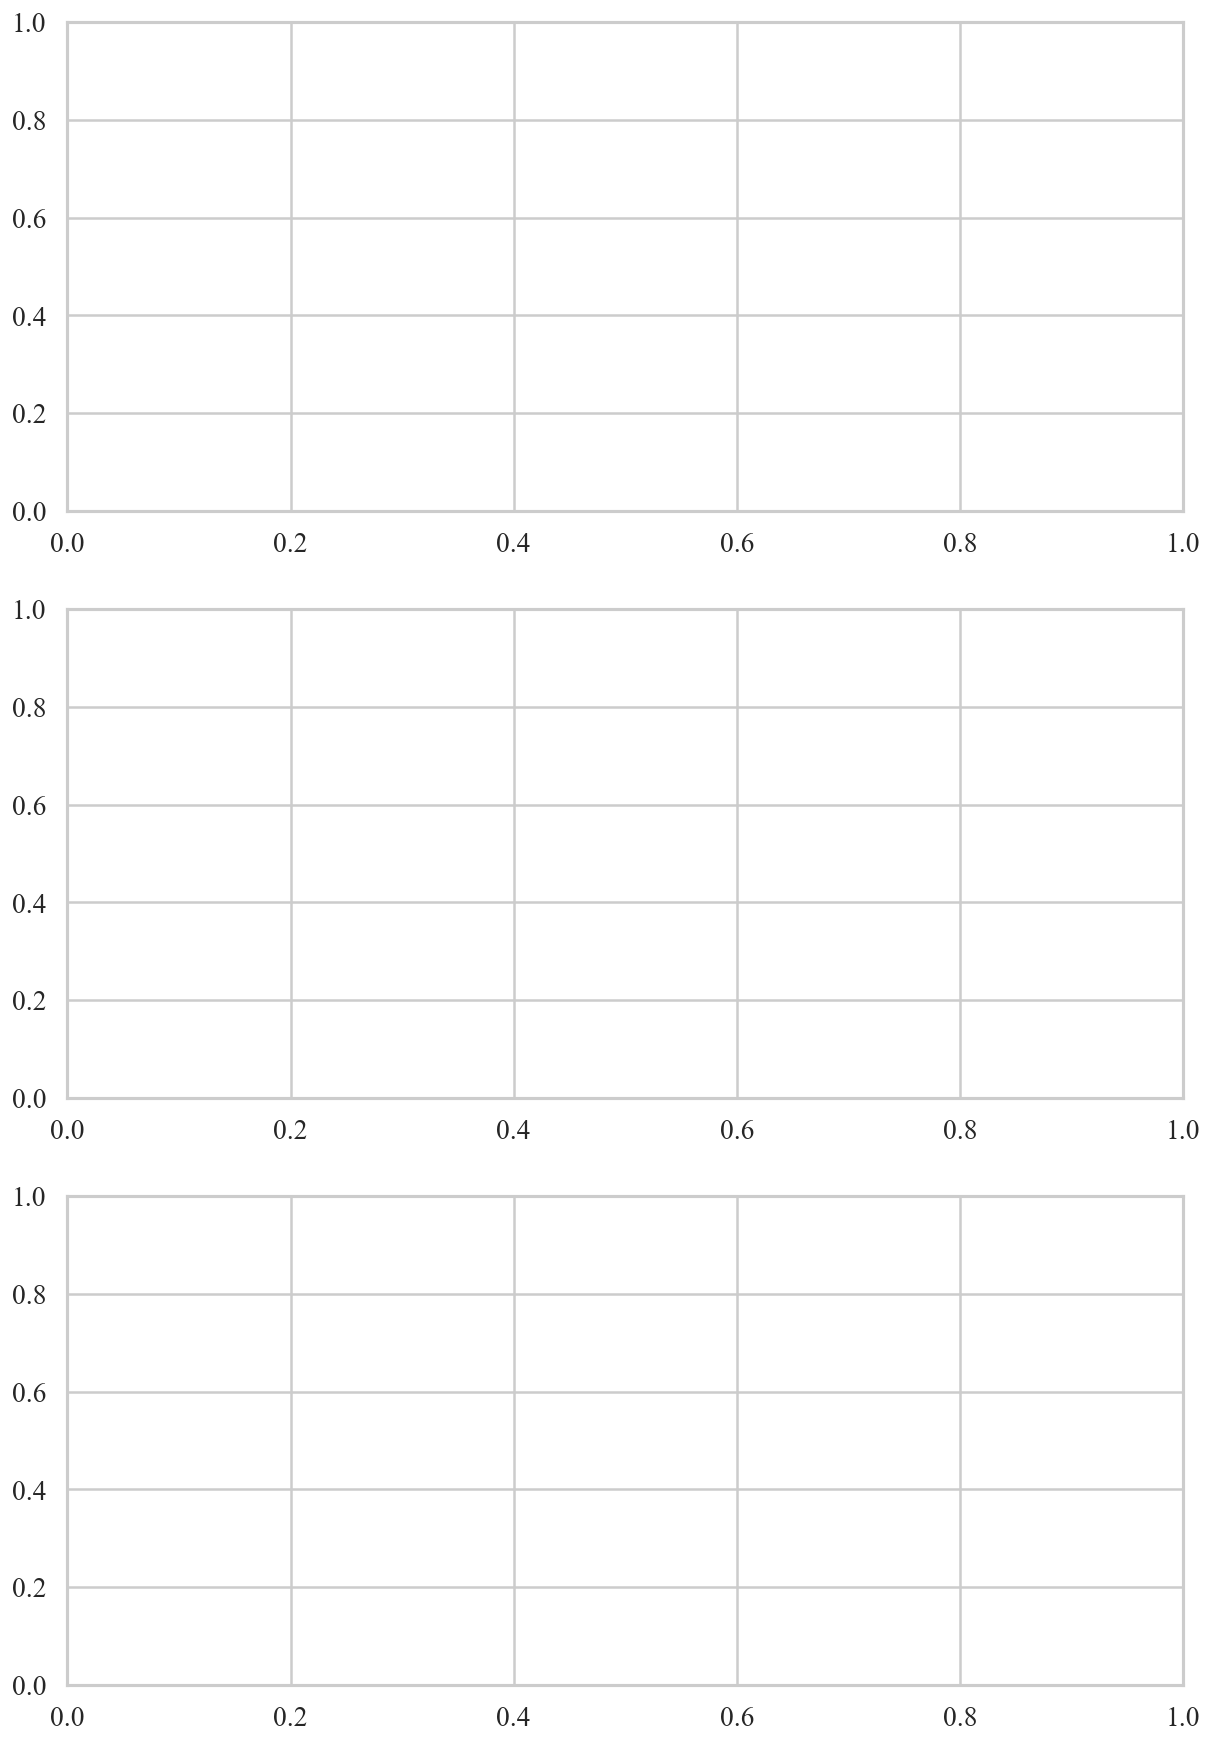

In [40]:
plt.rcParams["font.family"] = ["Times New Roman"]
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
for ax, metric, title in zip(
    axes,
    ["rmse", "mae", "acc"],
    ["(a) RMSE", "(b) MAE", "(c) ACC"],
):
    sub = metrics_df[metrics_df["metric"] == metric]
    for model in models:
        part = sub[sub["model"] == model]
        ax.plot(part["lead"], part["value"], marker="o", linewidth=2.2, markersize=4, color=palette[model], label=model)
    ax.set_title(title,fontsize=18,pad=10)
    ax.set_xlabel("Time(hour)")
    ax.grid(alpha=0.25, linestyle="--")

axes[0].set_ylabel("RMSE (m/s)",fontsize=18)
axes[1].set_ylabel("MAE (m/s)",fontsize=18)
axes[2].set_ylabel("ACC",fontsize=18)
axes[2].set_ylim(0.2, 1.005)
axes[0].legend(loc="upper left", frameon=True)
axes[1].legend(loc="upper left", frameon=True)
axes[2].legend(loc="lower left", frameon=True)
axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels([f"{i}" for i in range(0, 24)])
axes[1].set_xticks(range(0, 24))
axes[1].set_xticklabels([f"{i}" for i in range(0, 24)])
axes[2].set_xticks(range(0, 24))
axes[2].set_xticklabels([f"{i}" for i in range(0, 24)])


fig.suptitle("Fig. 1 Style: Comparison of the Next 24 h of WSP by Each Algorithm", fontsize=18, y=1.0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_main_metrics.png", bbox_inches="tight")
plt.show()

## 4. Fig. 2 风格：冬夏季平均风速空间图

这组图用 4 行 × 3 列布局模拟论文中的季节平均场图：

- 前两行表示冬季真值与预测
- 后两行表示夏季真值与预测
- 三列分别对应 `lead = 1, 3, 6`

如果后面替换成真实数据，只需要把 `winter_true/pred` 和 `summer_true/pred` 换掉即可。

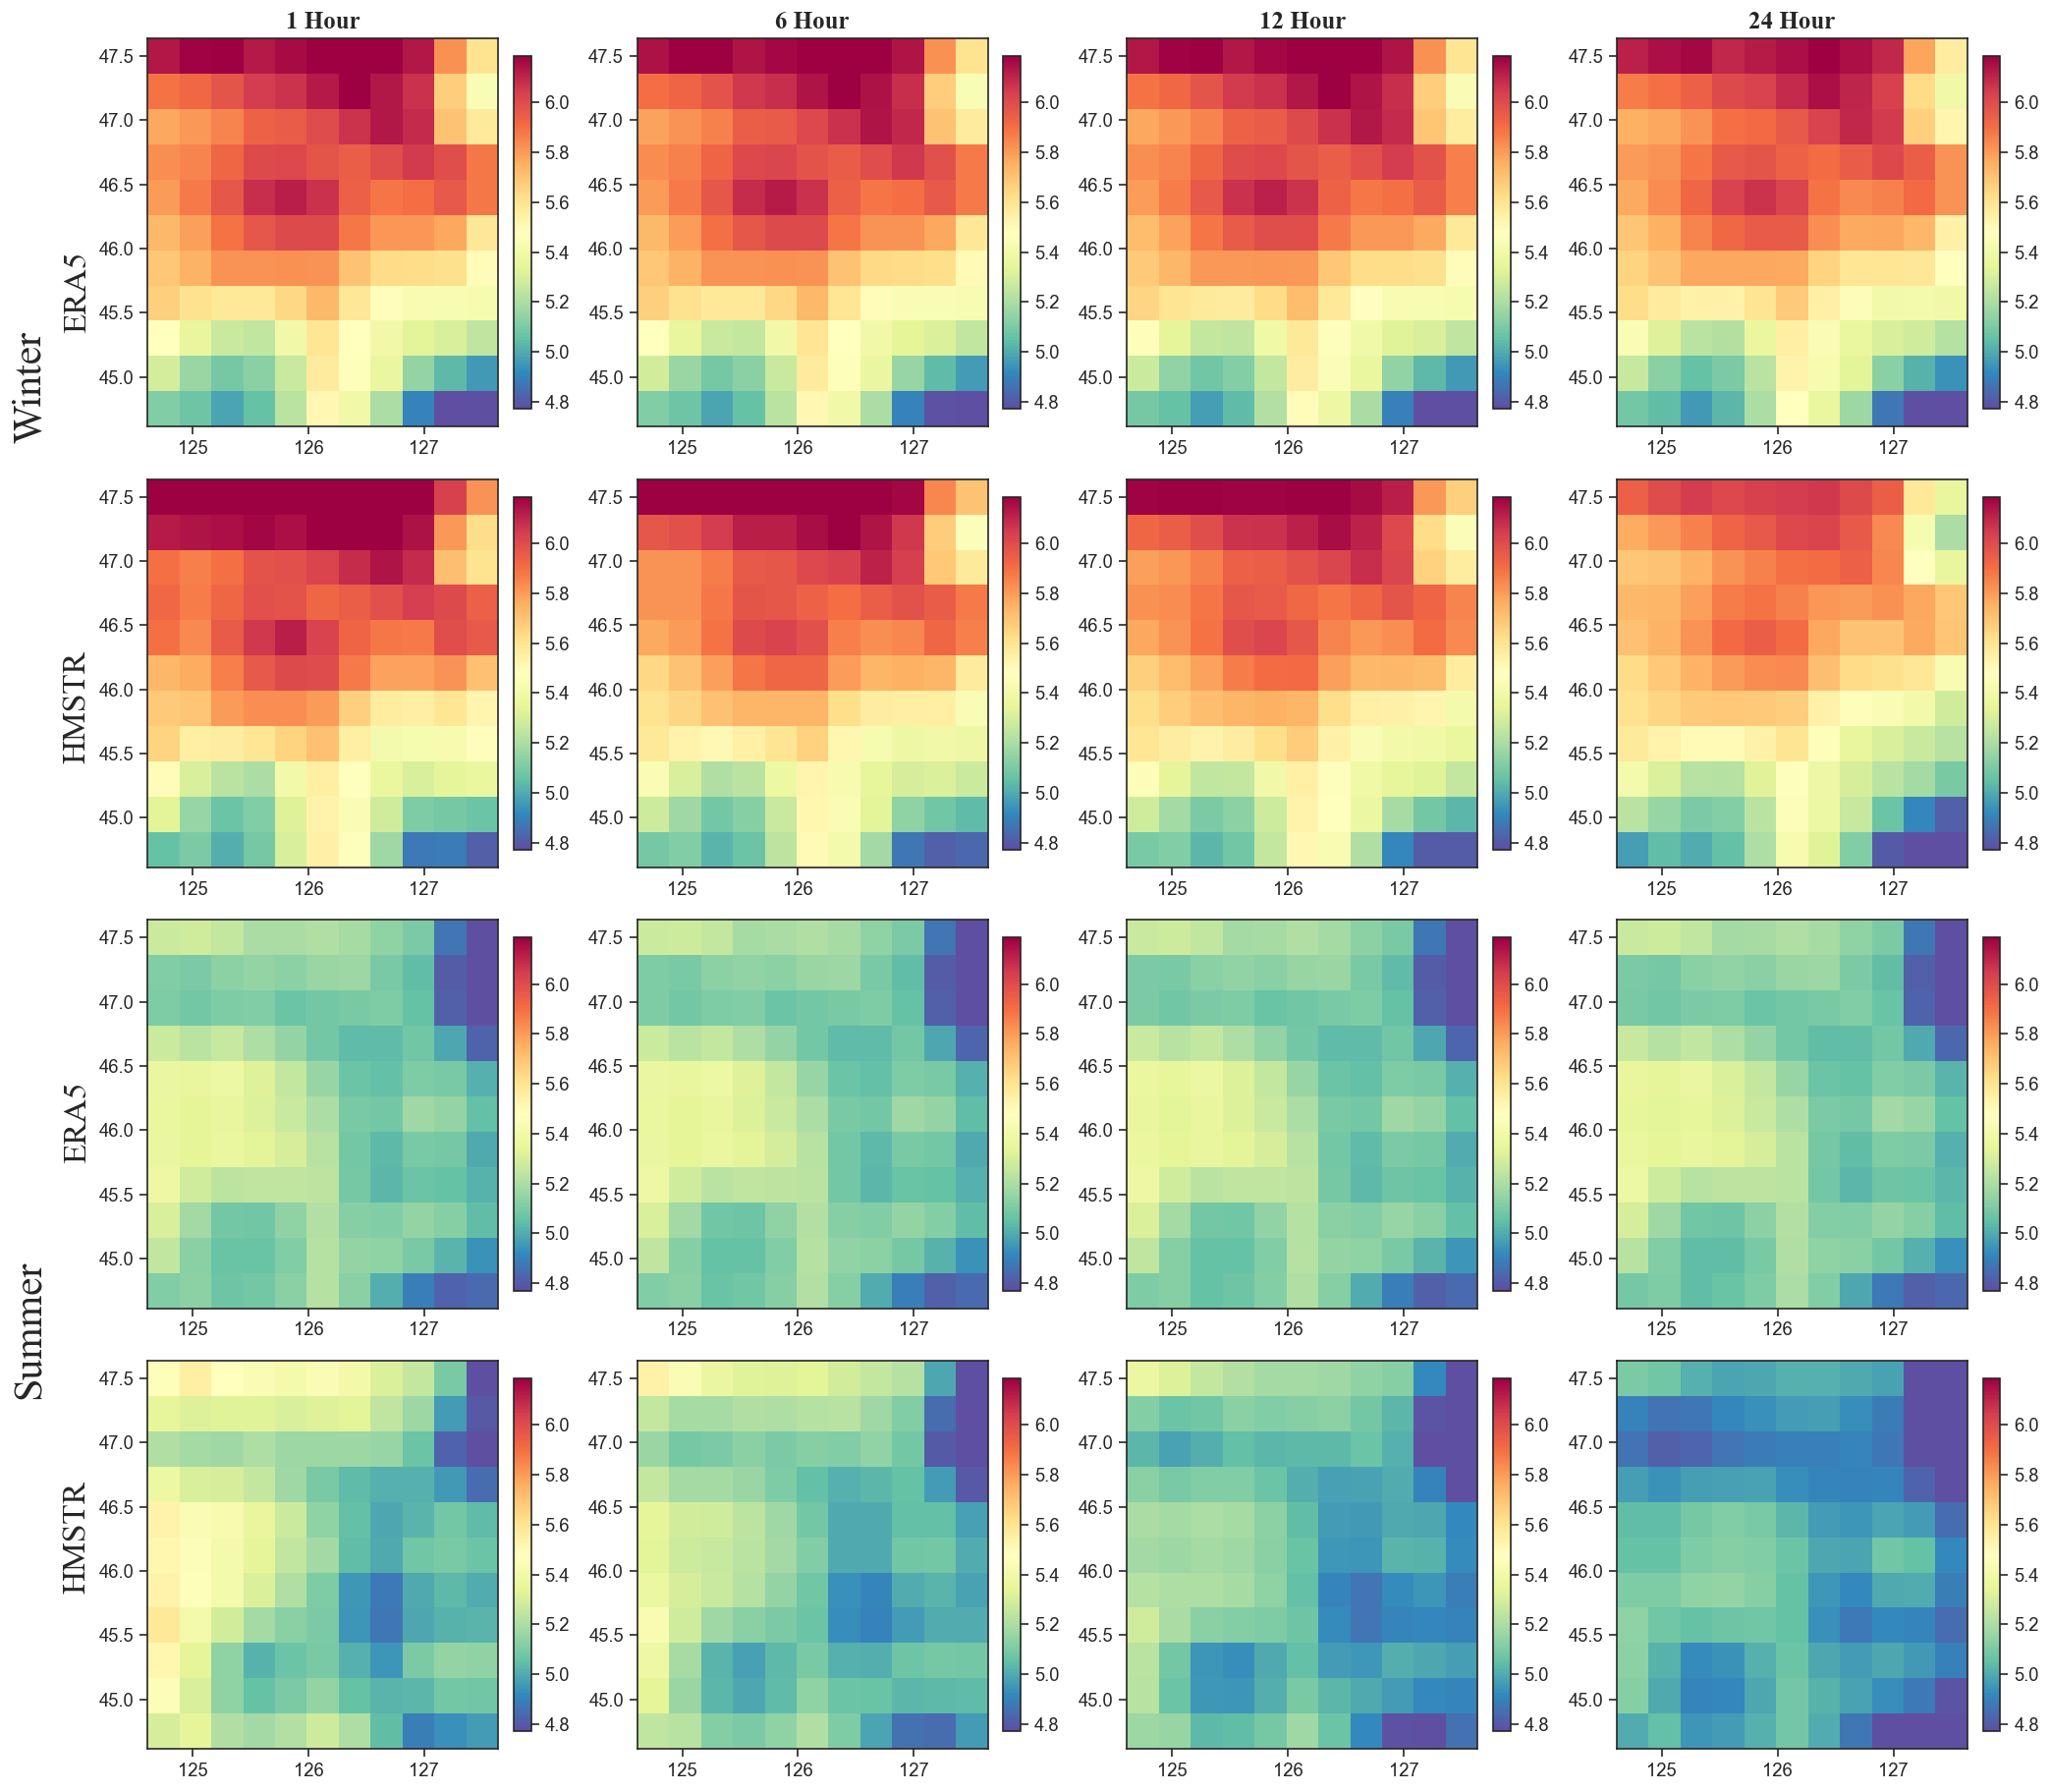

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = ["Times New Roman"]

sns.set_theme(style="ticks", context="paper", font_scale=1.25)

winter_speed_pred = np.load("../data/season/winter_pred_per_grid.npy")
summer_speed_pred = np.load("../data/season/summer_pred_per_grid.npy")
winter_speed_true = np.load("../data/season/winter_true_per_grid.npy")
summer_speed_true = np.load("../data/season/summer_true_per_grid.npy")
    

lat = np.linspace(44.75, 47.5, 11)
lon = np.linspace(124.75, 127.5, 11)
LON, LAT = np.meshgrid(lon, lat)

hours = [1, 6, 12, 24]

season_data = {
    "Winter_pred": {h: winter_speed_pred[h - 1] for h in hours},
    "Summer_pred": {h: summer_speed_pred[h - 1] for h in hours},
    "Winter_true": {h: winter_speed_true[h - 1] for h in hours},
    "Summer_true": {h: summer_speed_true[h - 1] for h in hours}
}


def plot_true_vs_pred():
    """绘制真实值与预测值的空间分布对比"""
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    
    # 计算全局颜色范围
    all_values = []
    for season_type in ["Winter_true", "Summer_true", "Winter_pred", "Summer_pred"]:
        for h in hours:
            all_values.extend(season_data[season_type][h].flatten())
    vmin, vmax = np.percentile(all_values, [2, 98])
    
    for i, h in enumerate(hours):
        # 冬季真实值
        ax = axes[0, i]
        im = ax.pcolormesh(LON, LAT, season_data["Winter_true"][h], 
                          cmap='viridis', vmin=vmin, vmax=vmax, shading='auto')
        ax.set_title(f'{h} Hour', fontsize=15, fontweight='bold',fontfamily="Times New Roman")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # 冬季预测值
        ax = axes[1, i]
        im = ax.pcolormesh(LON, LAT, season_data["Winter_pred"][h], 
                          cmap='viridis', vmin=vmin, vmax=vmax, shading='auto')
        #ax.set_title(f'Winter Pred - Hour {h}', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # 夏季真实值
        ax = axes[2, i]
        im = ax.pcolormesh(LON, LAT, season_data["Summer_true"][h], 
                          cmap='viridis', vmin=vmin, vmax=vmax, shading='auto')
        #ax.set_title(f'Summer True - Hour {h}', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # 夏季预测值
        ax = axes[3, i]
        im = ax.pcolormesh(LON, LAT, season_data["Summer_pred"][h], 
                          cmap='viridis', vmin=vmin, vmax=vmax, shading='auto')
        #ax.set_title(f'Summer Pred - Hour {h}', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    fig.text(
    x=0.04,          # 画布左侧的位置
    y=0.75,          # 第 1-2 行的垂直中间位置
    s='Winter',
    rotation='vertical',  # 文字垂直排列
    va='center',     # 垂直居中
    ha='center',     # 水平居中
    fontsize=25,
    fontfamily="Times New Roman"
    )
    fig.text(
    x=0.04,          
    y=0.25,          
    s='Summer',
    rotation='vertical',  # 文字垂直排列
    va='center',     # 垂直居中
    ha='center',     # 水平居中
    fontsize=25,
    fontfamily="Times New Roman"
    )
    method_labels = ['ERA5', 'HMSTR', 'ERA5', 'HMSTR']
    row_centers = [0.8, 0.58, 0.36, 0.14]  # 每一行的垂直中心
    for i, (label, y_pos) in enumerate(zip(method_labels, row_centers)):
        fig.text(
            x=0.06,
            y=y_pos,
            s=label,
            rotation='vertical',
            va='center',
            ha='center',
            fontsize=20,
            fontfamily="Times New Roman"
        )

    # plt.suptitle('Fig. 2 Wind Speed Spatial Distribution: True vs Predicted', 
    #              fontsize=18, fontweight='bold',y=1.0)
    plt.tight_layout(rect=[0.06, 0, 0.9, 0.96])
    plt.savefig('../figures/true_vs_pred_spatial.png', dpi=300, bbox_inches='tight')
    plt.show()
plot_true_vs_pred()

## 5. Fig. 3 风格：局地矢量风场图

底图表示风速，箭头表示风向和风速大小。这里分别给出冬季和夏季的真值/预测对照图。

风速范围: 0.00 - 8.96 m/s


C:\Users\16431\AppData\Local\Temp\ipykernel_8492\1934580835.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0, 0.9, 1])


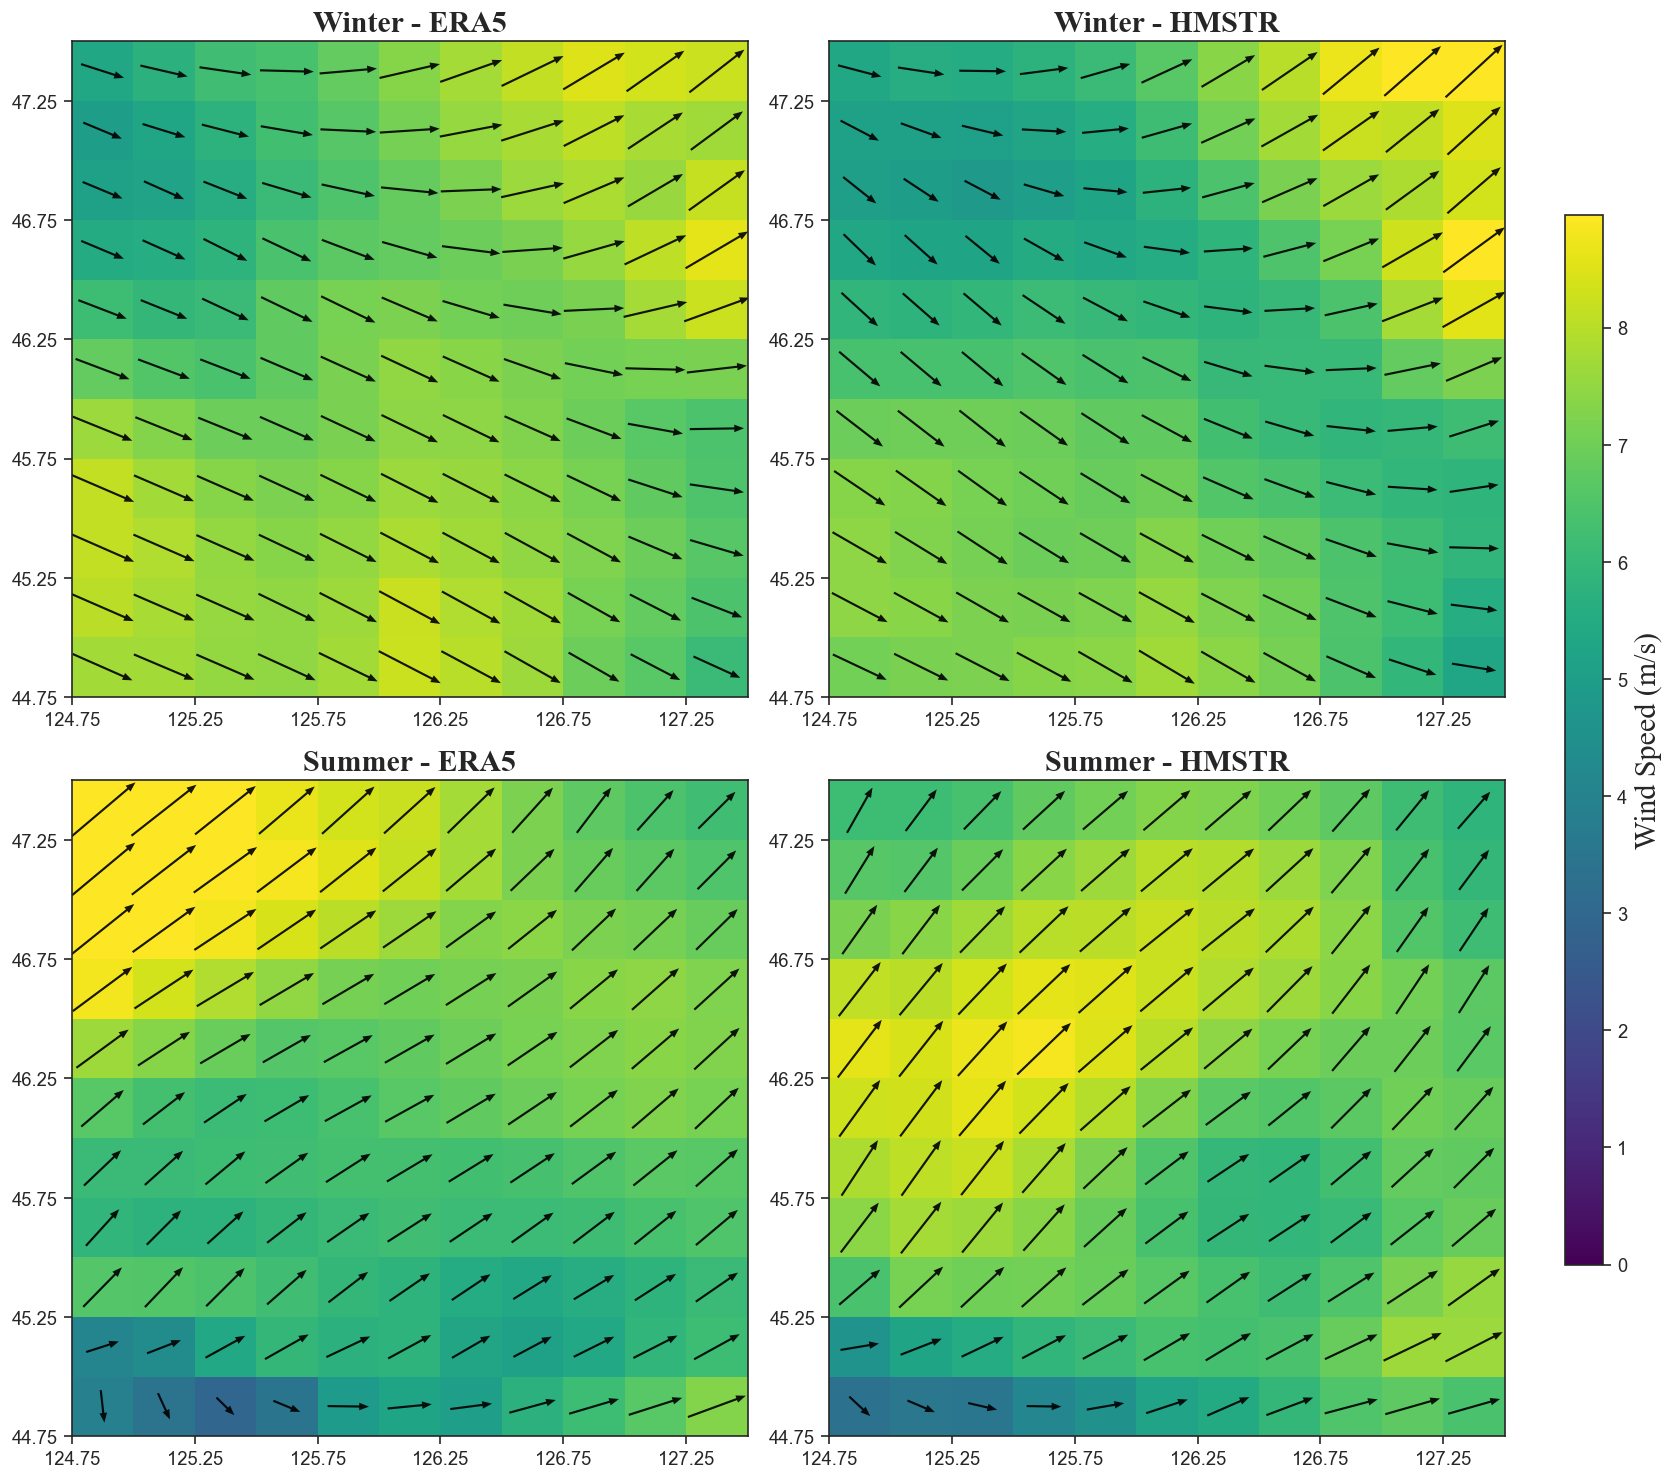

In [27]:
winter_speed_pred = np.load("../data/season/winter_pred.npy")
summer_speed_pred = np.load("../data/season/summer_pred.npy")
winter_speed_true = np.load("../data/season/winter_true.npy")
summer_speed_true = np.load("../data/season/summer_true.npy")

winter_pred_11 = winter_speed_pred[0,0]
winter_true_11 = winter_speed_true[0,0]
summer_pred_81 = summer_speed_pred[6,0]
summer_true_81 = summer_speed_true[6,0]
#1464
winter_speed_pred_11 = np.sqrt(winter_pred_11[0,:,:] ** 2 + winter_pred_11[1,:,:] ** 2)
winter_speed_true_11 = np.sqrt(winter_true_11[0,:,:] ** 2 + winter_true_11[1,:,:] ** 2)
summer_speed_pred_81 = np.sqrt(summer_pred_81[0,:,:] ** 2 + summer_pred_81[1,:,:] ** 2)
summer_speed_true_81 = np.sqrt(summer_true_81[0,:,:] ** 2 + summer_true_81[1,:,:] ** 2)

winter_u_pred = winter_pred_11[0, :, :]
winter_v_pred = winter_pred_11[1, :, :]
winter_u_true = winter_true_11[0, :, :]
winter_v_true = winter_true_11[1, :, :]

summer_u_pred = summer_pred_81[0, :, :]
summer_v_pred = summer_pred_81[1, :, :]
summer_u_true = summer_true_81[0, :, :]
summer_v_true = summer_true_81[1, :, :]

# 网格边界（12个点，形成11个网格单元）
lon_edges = np.linspace(124.75, 127.5, 12)
lat_edges = np.linspace(44.75, 47.5, 12)

# 网格中心（11个点）
lon_center = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_center = (lat_edges[:-1] + lat_edges[1:]) / 2
LON_center, LAT_center = np.meshgrid(lon_center, lat_center)

all_speeds = np.concatenate([
    winter_speed_true_11.flatten(),
    winter_speed_pred_11.flatten(),
    summer_speed_true_81.flatten(),
    summer_speed_pred_81.flatten()
])
vmin, vmax = 0, np.percentile(all_speeds, 98)
print(f"风速范围: {vmin:.2f} - {vmax:.2f} m/s")

fig, axes = plt.subplots(2, 2, figsize=(16, 12.5))
data_list = [
    (winter_speed_true_11, winter_u_true, winter_v_true, 'Winter', 'ERA5'),
    (winter_speed_pred_11, winter_u_pred, winter_v_pred, 'Winter', 'HMSTR'),
    (summer_speed_true_81, summer_u_true, summer_v_true, 'Summer', 'ERA5'),
    (summer_speed_pred_81, summer_u_pred, summer_v_pred, 'Summer', 'HMSTR')
]

for idx, (ax, (speed, u, v, season, data_type)) in enumerate(zip(axes.flat, data_list)):
    # 绘制底图
  
    im = ax.pcolormesh(lon_edges, lat_edges, speed, cmap='viridis', 
                   vmin=vmin, vmax=vmax,shading='auto',  
                   )
    
    # 绘制箭头（每个网格点绘制一个）
    step = 1
    speed_plot = speed[::step, ::step]
    
    q = ax.quiver(LON_center[::step, ::step], LAT_center[::step, ::step],
                 u[::step, ::step], v[::step, ::step],
                 color='black', scale=80, width=0.0032, 
                 headwidth=3.5, headlength=4.5, alpha=0.9,pivot="middle",)
    
    ax.set_title(f'{season} - {data_type}', fontsize=18, fontweight='bold',fontfamily="Times New Roman")
    ax.set_xlim(lon_edges.min(), lon_edges.max())
    ax.set_ylim(lat_edges.min(), lat_edges.max())
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_xticks(np.arange(124.75, 127.5, 0.5))
    ax.set_yticks(np.arange(44.75, 47.5, 0.5))



# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cbar_ax, orientation='vertical')
cbar.set_label('Wind Speed (m/s)', fontsize=18,fontfamily="Times New Roman")

#plt.suptitle('Wind Speed and Direction Comparison (Quiver)', 
             #fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.1, 0, 0.9, 1])
plt.savefig('../figures/wind_comparison_quiver.png', dpi=300, bbox_inches='tight')
plt.show()



## 6. Fig. 4 风格：关键站点风玫瑰图

这里做成 2 行 × 3 列：

- 第一行是 Chifeng
- 第二行是 Harbin
- 每行依次为 ERA5 / MFWPN / YourModel

图例中不同颜色对应不同风速区间。

(10517, 24, 2, 11, 11)
(10517, 24, 11, 11, 2)
(10517, 24, 11, 11, 2)


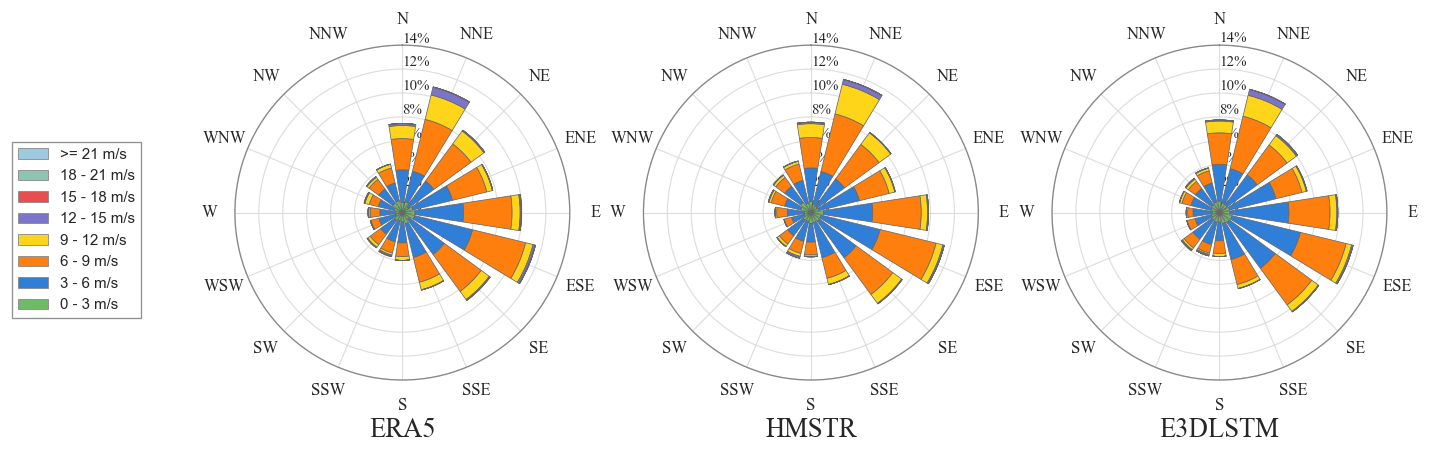

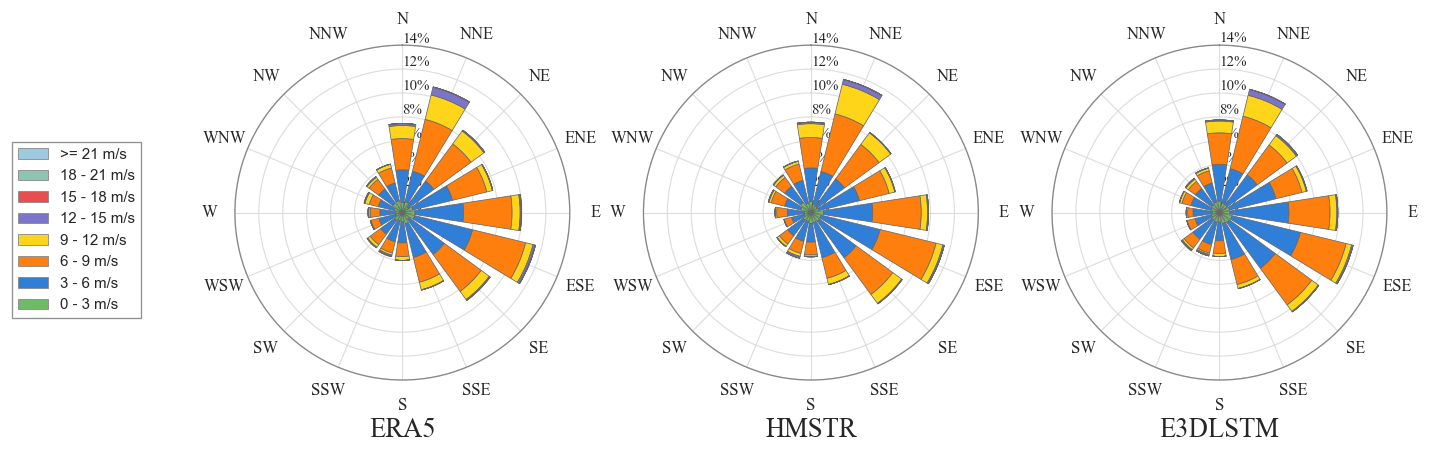

In [30]:
import pickle
RESULT_PATH = Path("../output/vst-conv_test.npz")
FIGURE_PATH = Path("../figures/harbin_windrose.png")
E3DLSTM_PATH = r'D:/风速预测/data/e3dlstm/preds.npy'
# E3DLSTM_PATH = "D:/风速预测/data/e3dlstm/preds.npy"



def extract_wind_data_at_location(data, lat_idx, lon_idx):
    """Return flattened u/v series at one grid point.

    Expected project formats:
        [N, T, C, H, W] or [T, C, H, W], where C=2 and C0/C1 are u/v.
    """
    if data.ndim == 5:
        u = data[:, :, 0, lat_idx, lon_idx]
        v = data[:, :, 1, lat_idx, lon_idx]
    elif data.ndim == 4:
        u = data[:, 0, lat_idx, lon_idx]
        v = data[:, 1, lat_idx, lon_idx]
    else:
        raise ValueError(f"Unexpected data shape: {data.shape}")
    return u.reshape(-1), v.reshape(-1)


def calculate_wind_speed_direction(u, v, direction_mode="towards"):
    speed = np.sqrt(u ** 2 + v ** 2)

    # atan2 returns mathematical angle from east, counter-clockwise.
    angle_from_east = np.degrees(np.arctan2(v, u))
    direction_towards = (90 - angle_from_east) % 360

    if direction_mode == "from":
        direction = (direction_towards + 180) % 360
    elif direction_mode == "towards":
        direction = direction_towards
    else:
        raise ValueError("direction_mode must be 'towards' or 'from'.")

    valid = np.isfinite(speed) & np.isfinite(direction)
    return speed[valid], direction[valid]

def windrose_frequency(speed, direction, speed_bins, n_sector=16):
    direction = np.asarray(direction) % 360
    speed = np.asarray(speed)

    sector_width = 360 / n_sector
    sector_idx = np.floor((direction + sector_width / 2) % 360 / sector_width).astype(int)
    speed_idx = np.digitize(speed, speed_bins, right=False) - 1
    speed_idx = np.clip(speed_idx, 0, len(speed_bins) - 2)

    table = np.zeros((len(speed_bins) - 1, n_sector), dtype=float)
    for s_idx, d_idx in zip(speed_idx, sector_idx):
        table[s_idx, d_idx] += 1

    if table.sum() > 0:
        table = table / table.sum() * 100
    return table


def plot_one_windrose(ax, speed, direction, title, speed_bins, colors, rmax=14):
    labels = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
              "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
    n_sector = len(labels)
    theta = np.deg2rad(np.arange(0, 360, 360 / n_sector))
    width = np.deg2rad(360 / n_sector * 0.78)

    freq = windrose_frequency(speed, direction, speed_bins, n_sector=n_sector)
    bottom = np.zeros(n_sector)
    for i, color in enumerate(colors):
        ax.bar(
            theta,
            freq[i],
            width=width,
            bottom=bottom,
            align="center",
            color=color,
            edgecolor="#666666",
            linewidth=0.45,
        )
        bottom += freq[i]

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(theta)
    ax.set_xticklabels(labels, fontfamily="Times New Roman", fontsize=10)
    ax.set_ylim(0, rmax)
    ax.set_yticks([0,2,4,6,8,10,12,14])
    ax.set_yticklabels(["0%","2%", "4%", "6%", "8%", "10%","12%","14%"], fontfamily="Times New Roman", fontsize=9)
    ax.set_rlabel_position(0)
    ax.grid(color="#D8D8D8", linewidth=0.7, alpha=0.85)
    ax.spines["polar"].set_color("#888888")
    ax.spines["polar"].set_linewidth(0.8)
    ax.set_title(title, y=-0.20, fontfamily="Times New Roman", fontsize=16)


def plot_windrose(speed_true, dir_true, speed_pred, dir_pred,speed_predrnn,dir_predrnn):
    speed_bins = np.array([0, 3, 6, 9, 12, 15, 18, 21, np.inf], dtype=float)
    colors = [
        "#6dbb67",  # 0-3
        "#2f7ed8",  # 3-6
        "#ff7f0e",  # 6-9
        "#ffd51a",  # 9-12
        "#7b74c9",  # 12-15
        "#e84d4f",  # 15-18
        "#8cc6b0",  # 18-21
        "#9ecae1",  # >=21
    ]

    fig = plt.figure(figsize=(12, 4.8))
    ax_true = fig.add_subplot(1, 3, 1, projection="polar")
    ax_pred = fig.add_subplot(1, 3, 2, projection="polar")
    ax_predrnn = fig.add_subplot(1,3,3,projection="polar")

    plot_one_windrose(ax_true, speed_true, dir_true, "ERA5", speed_bins, colors)
    plot_one_windrose(ax_pred, speed_pred, dir_pred, "HMSTR", speed_bins, colors)
    plot_one_windrose(ax_predrnn, speed_predrnn, dir_predrnn, "E3DLSTM", speed_bins, colors)

    legend_labels = [
        ">= 21 m/s", "18 - 21 m/s", "15 - 18 m/s", "12 - 15 m/s",
        "9 - 12 m/s", "6 - 9 m/s", "3 - 6 m/s", "0 - 3 m/s",
    ]
    legend_colors = list(reversed(colors))
    handles = [
        Patch(facecolor=color, edgecolor="#888888", linewidth=0.5, label=label)
        for color, label in zip(legend_colors, legend_labels)
    ]
    fig.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(0.02, 0.52),
        frameon=True,
        fancybox=False,
        edgecolor="#777777",
        fontsize=9,
    )

    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.14, top=0.96, wspace=0.22)
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


result = np.load(RESULT_PATH)
pred_predrnn = np.load(E3DLSTM_PATH)
with open(r"D:/风速预测/output/model/LSTM2D/20260622_010020/scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)


shape = pred_predrnn.shape
print(pred_predrnn.shape)

pred_predrnn1 = np.transpose(pred_predrnn, (0, 1, 3, 4, 2))
print(pred_predrnn1.shape)
pred_predrnn2 = scaler_y.inverse_transform(
    pred_predrnn1.reshape(-1, 2)
).reshape(pred_predrnn1.shape)
pred_predrnn3 = np.transpose(pred_predrnn2, (0, 1, 4, 2, 3))
print(pred_predrnn2.shape)


result_pred_2023 = result["pred"][1757:,0:6]
result_true_2023 = result["true"][1757:,0:6]


pred_predrnn_2023 = pred_predrnn3[1757:,0:6]

lat = np.linspace(44.75, 47.5, 12)
lon = np.linspace(124.75, 127.5, 12)

target_lat, target_lon = 45.8, 126.6
lat_idx = np.argmin(np.abs(lat - target_lat))
lon_idx = np.argmin(np.abs(lon - target_lon))

pred_u, pred_v = extract_wind_data_at_location(result_pred_2023, lat_idx, lon_idx)
true_u, true_v = extract_wind_data_at_location(result_true_2023, lat_idx, lon_idx)
pred_predrnn_u, pred_predrnn_v = extract_wind_data_at_location(pred_predrnn_2023, lat_idx, lon_idx)

speed_pred, dir_pred = calculate_wind_speed_direction(pred_u, pred_v, direction_mode="towards")
speed_true, dir_true = calculate_wind_speed_direction(true_u, true_v, direction_mode="towards")
speed_predrnn,dir_predrnn = calculate_wind_speed_direction(pred_predrnn_u,pred_predrnn_v,direction_mode="towards")

plot_windrose(speed_true, dir_true, speed_pred, dir_pred,speed_predrnn,dir_predrnn)

## 7.迁移学习结果

### 风速分布图

In [ ]:
import pickle
RESULT_PATH = Path("../output/transfer_learning/neimenggu/target_test_results.npz")
FIGURE_PATH = Path("../figures/transfer_learning/harbin_windrose.png")



def extract_wind_data_at_location(data, lat_idx, lon_idx):
    """Return flattened u/v series at one grid point.

    Expected project formats:
        [N, T, C, H, W] or [T, C, H, W], where C=2 and C0/C1 are u/v.
    """
    if data.ndim == 5:
        u = data[:, :, 0, lat_idx, lon_idx]
        v = data[:, :, 1, lat_idx, lon_idx]
    elif data.ndim == 4:
        u = data[:, 0, lat_idx, lon_idx]
        v = data[:, 1, lat_idx, lon_idx]
    else:
        raise ValueError(f"Unexpected data shape: {data.shape}")
    return u.reshape(-1), v.reshape(-1)


def calculate_wind_speed_direction(u, v, direction_mode="towards"):
    speed = np.sqrt(u ** 2 + v ** 2)

    # atan2 returns mathematical angle from east, counter-clockwise.
    angle_from_east = np.degrees(np.arctan2(v, u))
    direction_towards = (90 - angle_from_east) % 360

    if direction_mode == "from":
        direction = (direction_towards + 180) % 360
    elif direction_mode == "towards":
        direction = direction_towards
    else:
        raise ValueError("direction_mode must be 'towards' or 'from'.")

    valid = np.isfinite(speed) & np.isfinite(direction)
    return speed[valid], direction[valid]

def windrose_frequency(speed, direction, speed_bins, n_sector=16):
    direction = np.asarray(direction) % 360
    speed = np.asarray(speed)

    sector_width = 360 / n_sector
    sector_idx = np.floor((direction + sector_width / 2) % 360 / sector_width).astype(int)
    speed_idx = np.digitize(speed, speed_bins, right=False) - 1
    speed_idx = np.clip(speed_idx, 0, len(speed_bins) - 2)

    table = np.zeros((len(speed_bins) - 1, n_sector), dtype=float)
    for s_idx, d_idx in zip(speed_idx, sector_idx):
        table[s_idx, d_idx] += 1

    if table.sum() > 0:
        table = table / table.sum() * 100
    return table


def plot_one_windrose(ax, speed, direction, title, speed_bins, colors, rmax=14):
    labels = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
              "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
    n_sector = len(labels)
    theta = np.deg2rad(np.arange(0, 360, 360 / n_sector))
    width = np.deg2rad(360 / n_sector * 0.78)

    freq = windrose_frequency(speed, direction, speed_bins, n_sector=n_sector)
    bottom = np.zeros(n_sector)
    for i, color in enumerate(colors):
        ax.bar(
            theta,
            freq[i],
            width=width,
            bottom=bottom,
            align="center",
            color=color,
            edgecolor="#666666",
            linewidth=0.45,
        )
        bottom += freq[i]

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(theta)
    ax.set_xticklabels(labels, fontfamily="Times New Roman", fontsize=10)
    ax.set_ylim(0, rmax)
    ax.set_yticks([0,2,4,6,8,10,12,14])
    ax.set_yticklabels(["0%","2%", "4%", "6%", "8%", "10%","12%","14%"], fontfamily="Times New Roman", fontsize=9)
    ax.set_rlabel_position(0)
    ax.grid(color="#D8D8D8", linewidth=0.7, alpha=0.85)
    ax.spines["polar"].set_color("#888888")
    ax.spines["polar"].set_linewidth(0.8)
    ax.set_title(title, y=-0.20, fontfamily="Times New Roman", fontsize=16)


def plot_windrose(speed_true, dir_true, speed_pred, dir_pred,speed_predrnn,dir_predrnn):
    speed_bins = np.array([0, 3, 6, 9, 12, 15, 18, 21, np.inf], dtype=float)
    colors = [
        "#6dbb67",  # 0-3
        "#2f7ed8",  # 3-6
        "#ff7f0e",  # 6-9
        "#ffd51a",  # 9-12
        "#7b74c9",  # 12-15
        "#e84d4f",  # 15-18
        "#8cc6b0",  # 18-21
        "#9ecae1",  # >=21
    ]

    fig = plt.figure(figsize=(12, 4.8))
    ax_true = fig.add_subplot(1, 3, 1, projection="polar")
    ax_pred = fig.add_subplot(1, 3, 2, projection="polar")
    ax_predrnn = fig.add_subplot(1,3,3,projection="polar")

    plot_one_windrose(ax_true, speed_true, dir_true, "ERA5", speed_bins, colors)
    plot_one_windrose(ax_pred, speed_pred, dir_pred, "VST-ConvLSTM", speed_bins, colors)
    plot_one_windrose(ax_predrnn, speed_predrnn, dir_predrnn, "E3DLSTM", speed_bins, colors)

    legend_labels = [
        ">= 21 m/s", "18 - 21 m/s", "15 - 18 m/s", "12 - 15 m/s",
        "9 - 12 m/s", "6 - 9 m/s", "3 - 6 m/s", "0 - 3 m/s",
    ]
    legend_colors = list(reversed(colors))
    handles = [
        Patch(facecolor=color, edgecolor="#888888", linewidth=0.5, label=label)
        for color, label in zip(legend_colors, legend_labels)
    ]
    fig.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(0.02, 0.52),
        frameon=True,
        fancybox=False,
        edgecolor="#777777",
        fontsize=9,
    )

    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.14, top=0.96, wspace=0.22)
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


result = np.load(RESULT_PATH)
pred_predrnn = np.load(pred_path)
with open(r"D:/风速预测/output/model/LSTM2D/20260622_010020/scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)


shape = pred_predrnn.shape

pred_predrnn = scaler_y.inverse_transform(
    pred_predrnn.reshape(-1, 2)
).reshape(shape)

result_pred_2023 = result["pred"][1757:,0]
result_true_2023 = result["true"][1757:,0]

# niemengu
lat = np.linspace(40, 42.75, 11)
lon = np.linspace(111, 123.75, 11)
target_lat, target_lon = 41, 113.1
#shanghai
# lat = np.linspace(29.75, 32.5, 11)
# lon = np.linspace(120, 122.75, 11)
#target_lat, target_lon = 31.1, 121.3
#yunnan
# lat = np.linspace(24, 26.75, 11)
# lon = np.linspace(99, 101.75.75, 11)
#target_lat, target_lon = 100.13, 26.51
#fujian
# lat = np.linspace(24, 26.75, 11)
# lon = np.linspace(117.25, 120, 11)
#target_lat, target_lon = 118.05, 24.28
#xinjiang
# lat = np.linspace(42, 44.75, 11)
# lon = np.linspace(87, 89.75, 11)
# target_lat, target_lon = 89, 42.9



lat_idx = np.argmin(np.abs(lat - target_lat))
lon_idx = np.argmin(np.abs(lon - target_lon))

pred_u, pred_v = extract_wind_data_at_location(result_pred_2023, lat_idx, lon_idx)
true_u, true_v = extract_wind_data_at_location(result_true_2023, lat_idx, lon_idx)

speed_pred, dir_pred = calculate_wind_speed_direction(pred_u, pred_v, direction_mode="towards")
speed_true, dir_true = calculate_wind_speed_direction(true_u, true_v, direction_mode="towards")

plot_windrose(speed_true, dir_true, speed_pred, dir_pred)

FileNotFoundError: [Errno 2] No such file or directory: '..\\output\\transfer_learning\\neimenggu\\target_test_results.npz'

### 风力玫瑰图

In [ ]:
import pickle
RESULT_PATH = Path("../output/transfer_learning/fujian/target_test_results.npz")
FIGURE_PATH = Path("../figures/transfer_learning/fujian_windrose.png")



def extract_wind_data_at_location(data, lat_idx, lon_idx):
    """Return flattened u/v series at one grid point.

    Expected project formats:
        [N, T, C, H, W] or [T, C, H, W], where C=2 and C0/C1 are u/v.
    """
    if data.ndim == 5:
        u = data[:, :, 0, lat_idx, lon_idx]
        v = data[:, :, 1, lat_idx, lon_idx]
    elif data.ndim == 4:
        u = data[:, 0, lat_idx, lon_idx]
        v = data[:, 1, lat_idx, lon_idx]
    else:
        raise ValueError(f"Unexpected data shape: {data.shape}")
    return u.reshape(-1), v.reshape(-1)


def calculate_wind_speed_direction(u, v, direction_mode="towards"):
    speed = np.sqrt(u ** 2 + v ** 2)

    # atan2 returns mathematical angle from east, counter-clockwise.
    angle_from_east = np.degrees(np.arctan2(v, u))
    direction_towards = (90 - angle_from_east) % 360

    if direction_mode == "from":
        direction = (direction_towards + 180) % 360
    elif direction_mode == "towards":
        direction = direction_towards
    else:
        raise ValueError("direction_mode must be 'towards' or 'from'.")

    valid = np.isfinite(speed) & np.isfinite(direction)
    return speed[valid], direction[valid]

def windrose_frequency(speed, direction, speed_bins, n_sector=16):
    direction = np.asarray(direction) % 360
    speed = np.asarray(speed)

    sector_width = 360 / n_sector
    sector_idx = np.floor((direction + sector_width / 2) % 360 / sector_width).astype(int)
    speed_idx = np.digitize(speed, speed_bins, right=False) - 1
    speed_idx = np.clip(speed_idx, 0, len(speed_bins) - 2)

    table = np.zeros((len(speed_bins) - 1, n_sector), dtype=float)
    for s_idx, d_idx in zip(speed_idx, sector_idx):
        table[s_idx, d_idx] += 1

    if table.sum() > 0:
        table = table / table.sum() * 100
    return table


def plot_one_windrose(ax, speed, direction, title, speed_bins, colors, rmax=14):
    labels = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
              "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
    n_sector = len(labels)
    theta = np.deg2rad(np.arange(0, 360, 360 / n_sector))
    width = np.deg2rad(360 / n_sector * 0.78)

    freq = windrose_frequency(speed, direction, speed_bins, n_sector=n_sector)
    bottom = np.zeros(n_sector)
    for i, color in enumerate(colors):
        ax.bar(
            theta,
            freq[i],
            width=width,
            bottom=bottom,
            align="center",
            color=color,
            edgecolor="#666666",
            linewidth=0.45,
        )
        bottom += freq[i]

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(theta)
    ax.set_xticklabels(labels, fontfamily="Times New Roman", fontsize=10)
    ax.set_ylim(0, rmax)
    ax.set_yticks([0,2,4,6,8,10,12,14])
    ax.set_yticklabels(["0%","2%", "4%", "6%", "8%", "10%","12%","14%"], fontfamily="Times New Roman", fontsize=9)
    ax.set_rlabel_position(0)
    ax.grid(color="#D8D8D8", linewidth=0.7, alpha=0.85)
    ax.spines["polar"].set_color("#888888")
    ax.spines["polar"].set_linewidth(0.8)
    ax.set_title(title, y=-0.20, fontfamily="Times New Roman", fontsize=16)


def plot_windrose(speed_true, dir_true, speed_pred, dir_pred):
    speed_bins = np.array([0, 3, 6, 9, 12, 15, 18, 21, np.inf], dtype=float)
    colors = [
        "#6dbb67",  # 0-3
        "#2f7ed8",  # 3-6
        "#ff7f0e",  # 6-9
        "#ffd51a",  # 9-12
        "#7b74c9",  # 12-15
        "#e84d4f",  # 15-18
        "#8cc6b0",  # 18-21
        "#9ecae1",  # >=21
    ]

    fig = plt.figure(figsize=(12, 4.8))
    ax_true = fig.add_subplot(1, 3, 1, projection="polar")
    ax_pred = fig.add_subplot(1, 3, 2, projection="polar")
   

    plot_one_windrose(ax_true, speed_true, dir_true, "ERA5", speed_bins, colors)
    plot_one_windrose(ax_pred, speed_pred, dir_pred, "VST-ConvLSTM", speed_bins, colors)
   

    legend_labels = [
        ">= 21 m/s", "18 - 21 m/s", "15 - 18 m/s", "12 - 15 m/s",
        "9 - 12 m/s", "6 - 9 m/s", "3 - 6 m/s", "0 - 3 m/s",
    ]
    legend_colors = list(reversed(colors))
    handles = [
        Patch(facecolor=color, edgecolor="#888888", linewidth=0.5, label=label)
        for color, label in zip(legend_colors, legend_labels)
    ]
    fig.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(0.02, 0.52),
        frameon=True,
        fancybox=False,
        edgecolor="#777777",
        fontsize=9,
    )

    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.14, top=0.96, wspace=0.22)
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


result = np.load(RESULT_PATH)
with open(r"D:/LWQ/wind-forecast-main/output/model/LSTM2D/20260622_010020/scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)



result_pred_2023 = result["pred"][1757:,0]
result_true_2023 = result["true"][1757:,0]

# niemengu
# lat = np.linspace(40, 42.75, 12)
# lon = np.linspace(111, 123.75, 12)
# target_lat, target_lon = 41, 113.1
#shanghai
# lat = np.linspace(29.75, 32.5, 11)
# lon = np.linspace(120, 122.75, 11)
# target_lat, target_lon = 31.1, 121.3
#yunnan
# lat = np.linspace(24, 26.75, 11)
# lon = np.linspace(99, 101.75.75, 11)
#target_lat, target_lon = 100.13, 26.51
#fujian
lat = np.linspace(24, 26.75, 11)
lon = np.linspace(117.25, 120, 11)
target_lat, target_lon = 118.05, 24.28
#xinjiang
# lat = np.linspace(42, 44.75, 11)
# lon = np.linspace(87, 89.75, 11)
# target_lat, target_lon = 89, 42.9



lat_idx = np.argmin(np.abs(lat - target_lat))
lon_idx = np.argmin(np.abs(lon - target_lon))

pred_u, pred_v = extract_wind_data_at_location(result_pred_2023, lat_idx, lon_idx)
true_u, true_v = extract_wind_data_at_location(result_true_2023, lat_idx, lon_idx)

speed_pred, dir_pred = calculate_wind_speed_direction(pred_u, pred_v, direction_mode="towards")
speed_true, dir_true = calculate_wind_speed_direction(true_u, true_v, direction_mode="towards")

plot_windrose(speed_true, dir_true, speed_pred, dir_pred)

FileNotFoundError: [Errno 2] No such file or directory: '..\\output\\transfer_learning\\fujian\\target_test_results.npz'

## 8.极端天气

In [3]:
import numpy as np
speed_data = np.load("../output/vst-conv_test.npz")
output_path = Path("../figures/wind_speed_timeseries.png")
true = speed_data["true"]
pred = speed_data["pred"]

y_pred_u = pred[1757:, :, 0, :, :]
y_pred_v = pred[1757:, :, 1, :, :]

y_true_u = true[1757:, :, 0, :, :]
y_true_v = true[1757:, :, 1, :, :]
def compute_wind_speed(u, v):
    return np.sqrt(u ** 2 + v ** 2)
y_true_speed = compute_wind_speed(y_true_u, y_true_v)
y_pred_speed = compute_wind_speed(y_pred_u, y_pred_v)

true_speed_lead1 = y_true_speed[:, 0, :, :]
# 筛选最大风速
regional_max_true_speed =true_speed_lead1.max(axis=(1, 2))
print("regional_max_true_speed shape:", regional_max_true_speed.shape)

#计算区域最大真实风速的 99% 分位数阈值
threshold_p99 = np.percentile(regional_max_true_speed, 95)
print(f"区域最大真实风速 99% 分位数阈值: {threshold_p99:.3f} m/s")
num_samples = len(regional_max_true_speed)
first_target_time = pd.Timestamp("2023-01-01 00:00:00")

records = []
for sample_idx in range(num_samples):

    
    sample_start_time = first_target_time + pd.Timedelta(hours=sample_idx)
    lead_idx = 0 
    target_time = sample_start_time + pd.Timedelta(hours=lead_idx)  # lead_idx 从 0 开始
    records.append({
        "sample_idx": sample_idx,
        "lead_hour": lead_idx + 1,
        "target_time": target_time,
        "regional_max_true_speed": regional_max_true_speed[sample_idx]
    })
    lead_idx += 1

df = pd.DataFrame(records)

extreme_events = df[df["regional_max_true_speed"] >= threshold_p99].copy()
print(extreme_events)
extreme_events.to_csv("../output/extreme_events.csv", index=False)



regional_max_true_speed shape: (8760,)
区域最大真实风速 99% 分位数阈值: 12.523 m/s
      sample_idx  lead_hour         target_time  regional_max_true_speed
237          237          1 2023-01-10 21:00:00                12.695310
238          238          1 2023-01-10 22:00:00                12.764565
239          239          1 2023-01-10 23:00:00                12.906587
240          240          1 2023-01-11 00:00:00                13.061772
241          241          1 2023-01-11 01:00:00                13.230720
...          ...        ...                 ...                      ...
8205        8205          1 2023-12-08 21:00:00                12.759359
8206        8206          1 2023-12-08 22:00:00                12.540271
8207        8207          1 2023-12-08 23:00:00                12.805888
8208        8208          1 2023-12-09 00:00:00                13.006288
8209        8209          1 2023-12-09 01:00:00                12.774492

[438 rows x 4 columns]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np

save_dir = Path("../figures/event_violin")
save_dir.mkdir(parents=True, exist_ok=True)
speed_data = np.load("../output/vst-conv_test.npz")
output_path = Path("../figures/wind_speed_timeseries.png")
true = speed_data["true"]
pred = speed_data["pred"]

y_pred_u = pred[1757:, :, 0, :, :]
y_pred_v = pred[1757:, :, 1, :, :]

y_true_u = true[1757:, :, 0, :, :]
y_true_v = true[1757:, :, 1, :, :]
def compute_wind_speed(u, v):
    return np.sqrt(u ** 2 + v ** 2)
y_true_speed = compute_wind_speed(y_true_u, y_true_v)
y_pred_speed = compute_wind_speed(y_pred_u, y_pred_v)

typical_events = [
    {
        "name": "Event A",
        "start_time": "2023-05-02 17:00:00",
        "end_time":   "2023-05-04 05:00:00",
        "desc": "Peak-intensity event"
    },
    {
        "name": "Event B",
        "start_time": "2023-05-25 03:00:00",
        "end_time":   "2023-05-27 03:00:00",
        "desc": "Longest-duration event"
    },
    {
        "name": "Event C",
        "start_time": "2023-11-06 17:00:00",
        "end_time":   "2023-11-08 5:00:00",
        "desc": "Winter representative event"
    }
]

# =====================================================
# 4. 参数设置
# =====================================================
# 预测时效，可改成 1 / 6 / 12 / 24
lead_hour = 12
lead_idx = lead_hour - 1

# true[0,0] 对应的真实时间
first_target_time = pd.Timestamp("2023-01-01 00:00:00")

# 按真实风速分箱
bins = [0, 3, 6, 10, 15, np.inf]
bin_labels = ["0–3", "3–6", "6–10", "10–15", ">15"]

# 绘图设置
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

def collect_event_errors(event, y_true_speed, y_pred_speed):
    start_time = pd.Timestamp(event["start_time"])
    end_time = pd.Timestamp(event["end_time"])

    event_times = pd.date_range(start=start_time, end=end_time, freq="h")

    bin_errors = {label: [] for label in bin_labels}

    for target_time in event_times:

        target_offset = int(
            (target_time - first_target_time) / pd.Timedelta(hours=1)
        )

        sample_idx = target_offset - lead_idx

        if sample_idx < 0 or sample_idx >= y_true_speed.shape[0]:
            continue

        true_grid = y_true_speed[sample_idx, lead_idx, :, :]
        pred_grid = y_pred_speed[sample_idx, lead_idx, :, :]

        error_grid = np.abs(pred_grid - true_grid)

        true_flat = true_grid.reshape(-1)
        error_flat = error_grid.reshape(-1)

        valid_mask = np.isfinite(true_flat) & np.isfinite(error_flat)
        true_flat = true_flat[valid_mask]
        error_flat = error_flat[valid_mask]

        bin_ids = np.digitize(true_flat, bins, right=False) - 1

        for i, label in enumerate(bin_labels):
            vals = error_flat[bin_ids == i]
            if len(vals) > 0:
                bin_errors[label].extend(vals.tolist())

    return bin_errors


# =====================================================
# 5. 预先统计所有事件误差
# =====================================================
all_event_errors = []
all_values = []

for event in typical_events:
    bin_errors = collect_event_errors(event, y_true_speed, y_pred_speed)
    all_event_errors.append(bin_errors)

    for label in bin_labels:
        vals = np.asarray(bin_errors[label], dtype=float)
        if len(vals) > 0:
            all_values.append(vals)


# 根据所有数据自动确定 y 轴上限
if len(all_values) > 0:
    all_values_flat = np.concatenate(all_values)
    y_max = np.nanpercentile(all_values_flat, 99.5) * 1.12
    y_max = max(y_max, 4.5)
else:
    y_max = 4.5

# Lead=1 h 图建议不要超过 5，否则留白太大
y_max = min(y_max, 5.0)


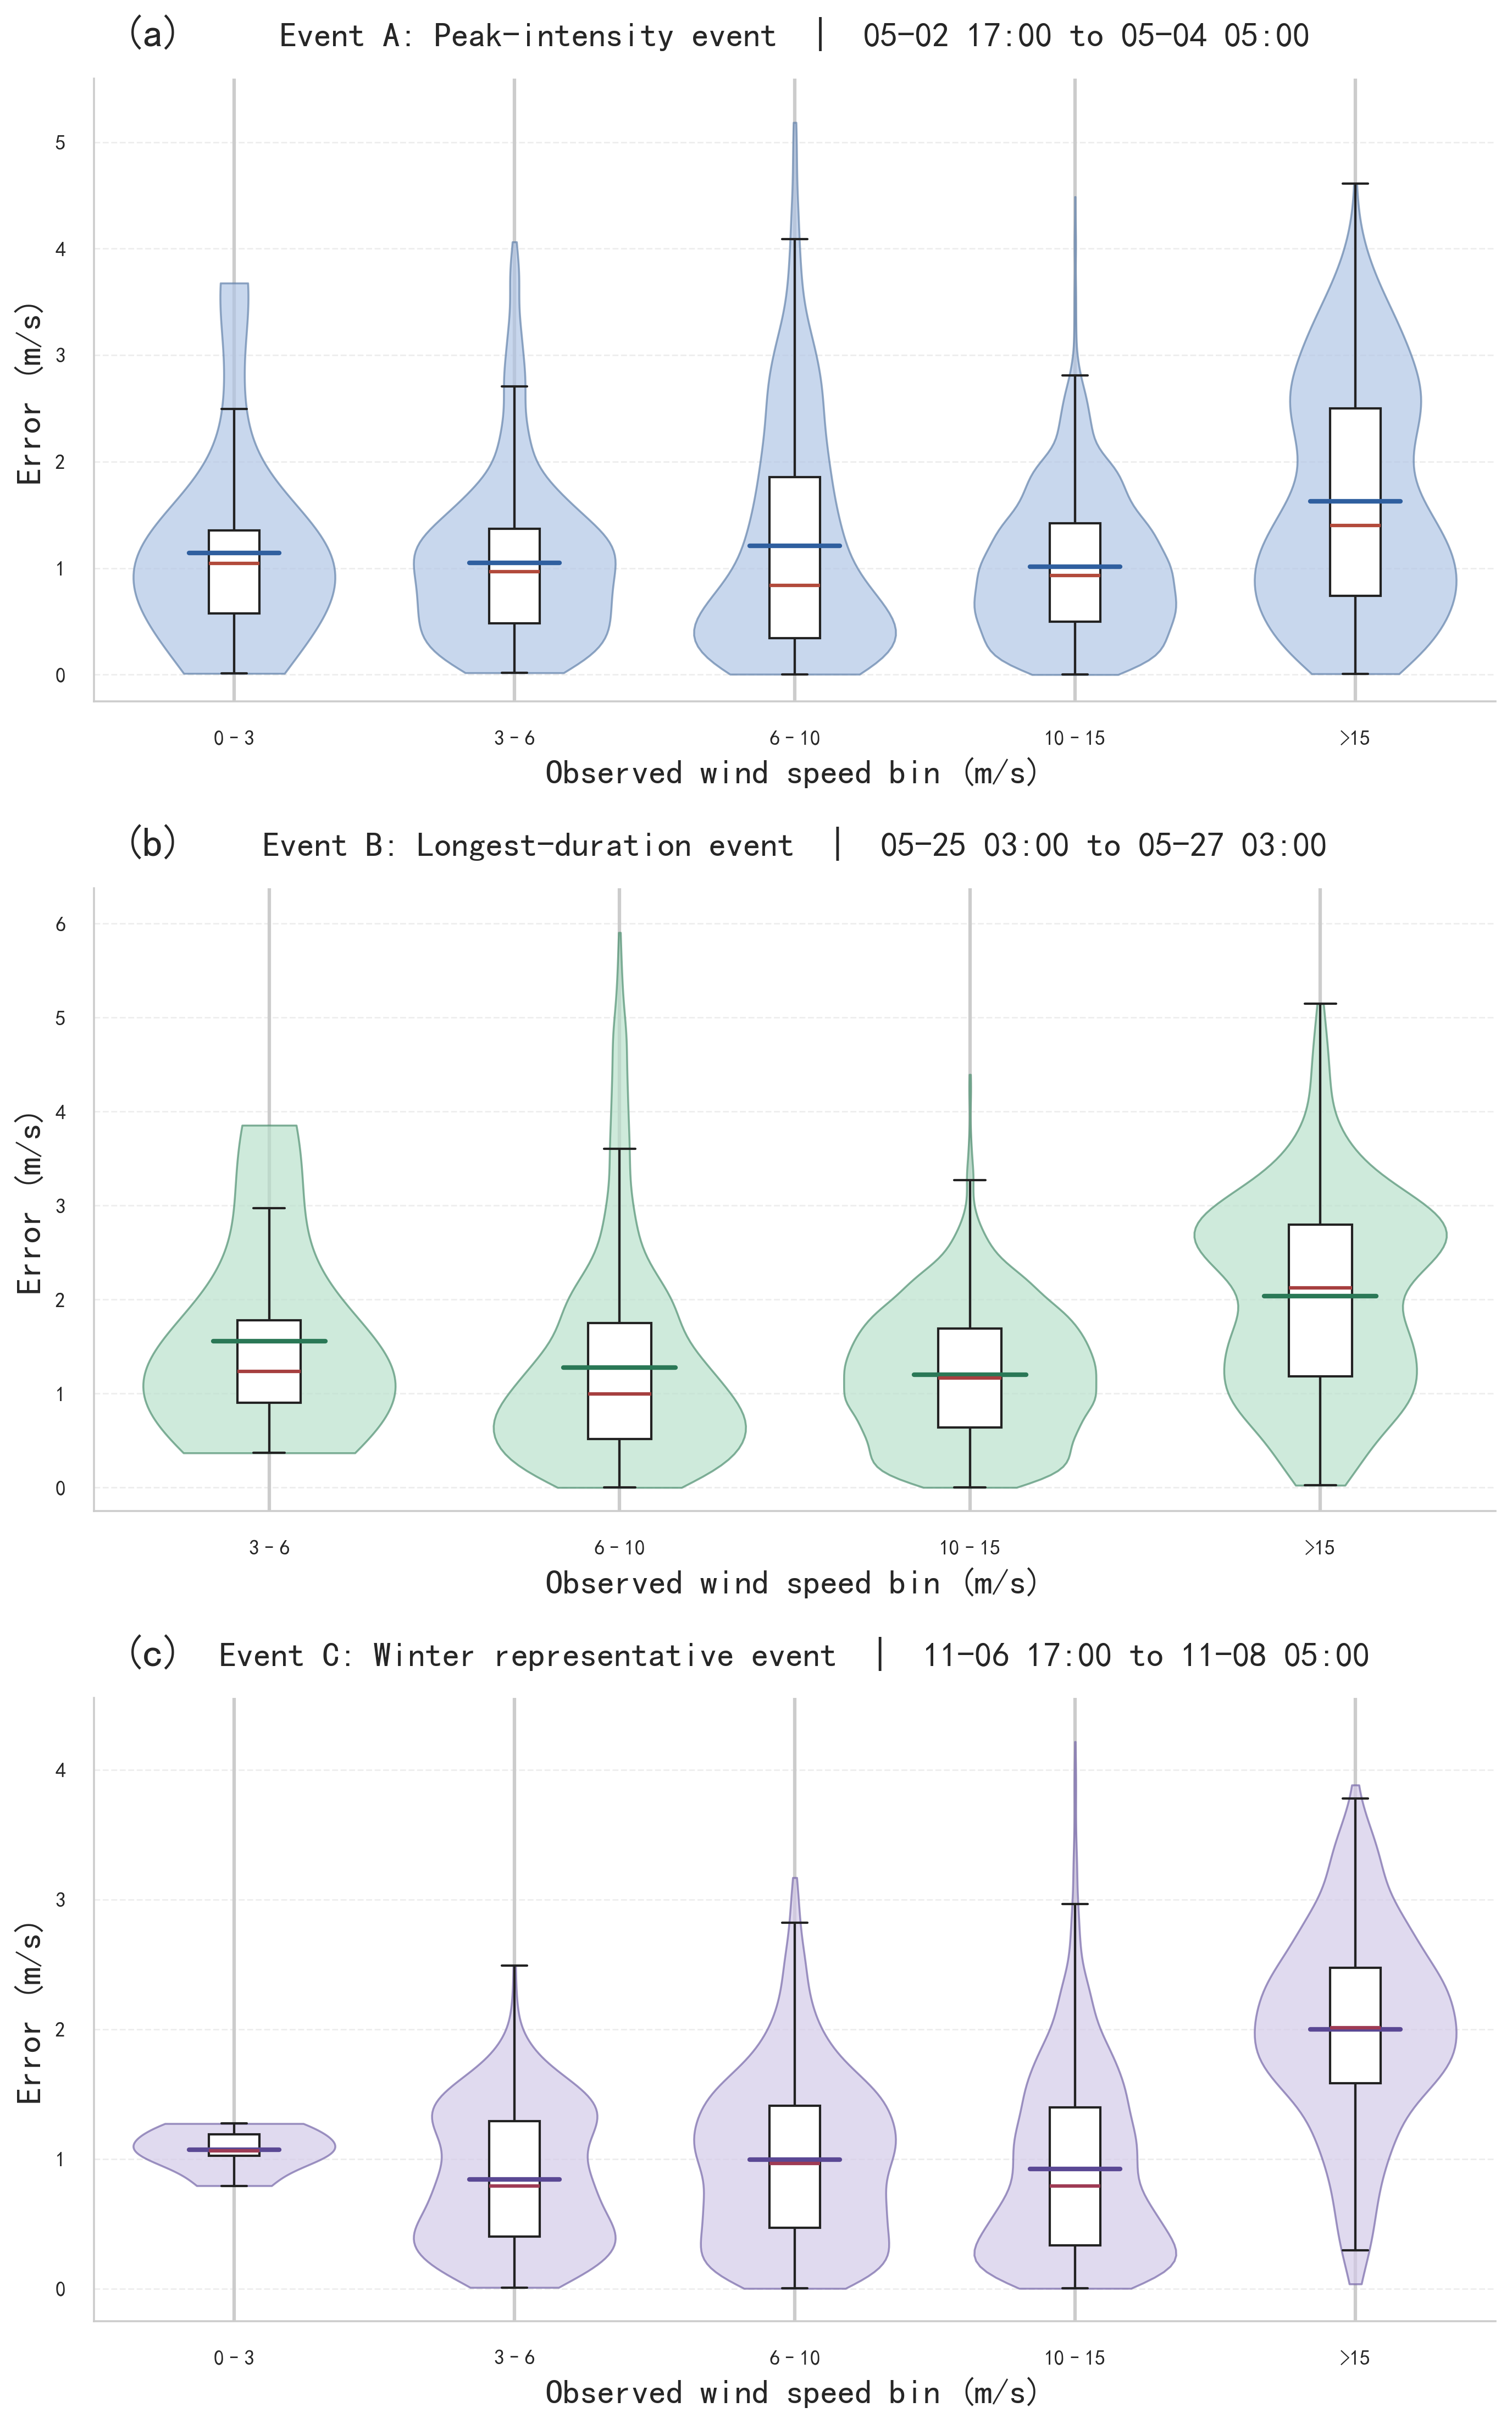

PNG 图已保存到: ..\figures\event_violin\typical_3_events_violin_12h_cycling_fixed_layout.png


In [8]:

import pandas as pd
import matplotlib.pyplot as plt

# 定义3套区分配色：对应 a/b/c 子图
panel_color_sets = [
    # (小提琴填充, 小提琴描边, 箱体中位数红, 均值蓝)
    {"violin_fill": "#AFC4E5", "violin_edge": "#5F7FA8", "median": "#B24A3B", "mean": "#2F5F9F"},  # a 浅蓝
    {"violin_fill": "#B8E0CB", "violin_edge": "#4A8C6D", "median": "#A63F3F", "mean": "#2A7856"},  # b 浅绿
    {"violin_fill": "#D2C9E8", "violin_edge": "#7263A6", "median": "#9E3B54", "mean": "#5A4894"},  # c 浅紫
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 16),
    dpi=300,
    sharex=False,
    sharey=False
)

panel_labels = ["a", "b", "c"]

# 循环时同步传入对应配色
for ax, event, bin_errors, panel_label, color_cfg in zip(
    axes,
    typical_events,
    all_event_errors,
    panel_labels,
    panel_color_sets
):
    plot_data = []
    plot_labels = []

    # 只保留有样本的风速等级
    for label in bin_labels:
        values = np.asarray(bin_errors[label], dtype=float)
        values = values[np.isfinite(values)]

        if len(values) > 0:
            plot_data.append(values)
            plot_labels.append(label)

    if len(plot_data) == 0:
        ax.set_title(f"{event['name']}: No valid samples", pad=14)
        continue

    positions_local = np.arange(1, len(plot_data) + 1)

    # =================================================
    # 每个子图单独计算 y 轴范围
    # =================================================
    event_values = np.concatenate(plot_data)

    local_y_max = np.nanpercentile(event_values, 99.5) * 1.25
    local_y_max = max(local_y_max, np.nanmax(event_values) * 1.08)
    local_y_max = max(local_y_max, 3.0)

    # =================================================
    # 小提琴图（使用当前面板专属配色）
    # =================================================
    violin = ax.violinplot(
        plot_data,
        positions=positions_local,
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body in violin["bodies"]:
        body.set_facecolor(color_cfg["violin_fill"])
        body.set_edgecolor(color_cfg["violin_edge"])
        body.set_alpha(0.68)
        body.set_linewidth(0.85)

    # =================================================
    # 箱线图
    # =================================================
    ax.boxplot(
        plot_data,
        positions=positions_local,
        widths=0.18,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color=color_cfg["median"], linewidth=1.5),
        boxprops=dict(
            facecolor="white",
            edgecolor="#222222",
            linewidth=1.0
        ),
        whiskerprops=dict(color="#222222", linewidth=1.0),
        capprops=dict(color="#222222", linewidth=1.0)
    )

    # =================================================
    # 均值线（面板专属均值色）
    # =================================================
    for pos, values in zip(positions_local, plot_data):
        mean_val = np.mean(values)
        ax.plot(
            [pos - 0.16, pos + 0.16],
            [mean_val, mean_val],
            color=color_cfg["mean"],
            linewidth=2.0,
            solid_capstyle="round"
        )

    # =================================================
    # 样本量标注
    # =================================================
    # for pos, values in zip(positions_local, plot_data):
    #     ax.text(
    #         pos,
    #         local_y_max * 0.96,
    #         f"n={len(values)}",
    #         ha="center",
    #         va="top",
    #         fontsize=8,
    #         color="#222222",
    #         clip_on=False
    #     )

    # =================================================
    # 标题：pad=14 拉大标题与绘图区域距离
    # =================================================
    start_time = pd.Timestamp(event["start_time"])
    end_time = pd.Timestamp(event["end_time"])

    ax.set_title(
        f"{event['name']}: {event['desc']}  |  "
        f"{start_time:%m-%d %H:%M} to {end_time:%m-%d %H:%M}",
        fontsize=15,
        pad=14  # 核心修改：标题距离图更远
    )

    # =================================================
    # (a)/(b)/(c) 固定左上角，不跟标题重叠
    # =================================================
    ax.text(
        0.02,
        1.1,
        f"({panel_label})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
    )

    # =================================================
    # 坐标轴设置
    # =================================================
    ax.set_xticks(positions_local)
    ax.set_xticklabels(plot_labels, fontsize=15)

    ax.set_xlabel("Observed wind speed bin (m/s)", fontsize=15)
    ax.set_ylabel("Error (m/s)", fontsize=15)

    # y下限-0.25 解决小提琴底部贴0尖锐问题
    ax.set_ylim(-0.25, local_y_max)

    # 网格美化
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.32)
    ax.set_axisbelow(True)

    # 边框美化
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.85)
    ax.spines["bottom"].set_linewidth(0.85)

    ax.tick_params(axis="both", labelsize=9)


# =====================================================
# 整体标题和布局
# =====================================================
plt.subplots_adjust(
    left=0.10,
    right=0.95,
    top=0.90,
    bottom=0.05,
    hspace=0.3  # 增大垂直子图间距，配合标题pad=14不拥挤
)

output_png = save_dir / "typical_3_events_violin_12h_cycling_fixed_layout.png"

plt.savefig(output_png, dpi=300, bbox_inches="tight")

plt.show()

print(f"PNG 图已保存到: {output_png}")

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =====================================================
# 1. 路径与基础设置
# =====================================================
save_dir = Path("../figures/wind_maps")
save_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# =====================================================
# 2. 读取数据
# =====================================================
speed_data = np.load("../output/vst-conv_test.npz")

true = speed_data["true"]
pred = speed_data["pred"]

# 2023年起始索引
start_idx = 1757
true = true[start_idx:]
pred = pred[start_idx:]

print("true shape:", true.shape)
print("pred shape:", pred.shape)

# true / pred shape: [N, 24, 2, H, W]

# =====================================================
# 3. 计算风速
# =====================================================
def compute_wind_speed(u, v):
    return np.sqrt(u ** 2 + v ** 2)

y_true_u = true[:, :, 0, :, :]
y_true_v = true[:, :, 1, :, :]

y_pred_u = pred[:, :, 0, :, :]
y_pred_v = pred[:, :, 1, :, :]

y_true_speed = compute_wind_speed(y_true_u, y_true_v)
y_pred_speed = compute_wind_speed(y_pred_u, y_pred_v)

print("y_true_speed shape:", y_true_speed.shape)
print("y_pred_speed shape:", y_pred_speed.shape)

# =====================================================
# 4. 构造“一天预报两次”的业务预报序列
#    每12小时起报一次，每次只取未来12小时
# =====================================================
first_target_time = pd.Timestamp("2023-01-01 00:00:00")

forecast_interval = 12   # 每12小时起报一次
use_lead_hours = 12      # 每次只取前12小时

num_samples = y_true_speed.shape[0]
H = y_true_speed.shape[2]
W = y_true_speed.shape[3]

cycle_indices = np.arange(
    0,
    num_samples - use_lead_hours + 1,
    forecast_interval
)

# 取前12小时
true_cycle = y_true_speed[cycle_indices, :use_lead_hours, :, :]
pred_cycle = y_pred_speed[cycle_indices, :use_lead_hours, :, :]

# 展平成连续时间序列
true_12h_series = true_cycle.reshape(-1, H, W)
pred_12h_series = pred_cycle.reshape(-1, H, W)

# 构造时间索引
time_list = []
for sample_idx in cycle_indices:
    cycle_start_time = first_target_time + pd.Timedelta(hours=int(sample_idx))
    for lead_idx in range(use_lead_hours):
        target_time = cycle_start_time + pd.Timedelta(hours=lead_idx)
        time_list.append(target_time)

time_index = pd.DatetimeIndex(time_list)

print("time_index length:", len(time_index))

# =====================================================
# 5. 三个典型事件
# =====================================================
typical_events = [
    {
        "name": "Event_A",
        "title": "Event A: Peak-intensity event",
        "start_time": "2023-05-02 17:00:00",
        "end_time":   "2023-05-04 05:00:00"
    },
    {
        "name": "Event_B",
        "title": "Event B: Longest-duration event",
        "start_time": "2023-05-25 03:00:00",
        "end_time":   "2023-05-27 03:00:00"
    },
    {
        "name": "Event_C",
        "title": "Event C: Winter representative event",
        "start_time": "2023-11-06 17:00:00",
        "end_time":   "2023-11-08 5:00:00"
    }
]

# =====================================================
# 6. 生成每隔12小时的绘图时间
# =====================================================
def generate_plot_times(start_time, end_time, interval_hours=12, include_end=True):
    start_time = pd.Timestamp(start_time)
    end_time = pd.Timestamp(end_time)

    times = list(pd.date_range(start=start_time, end=end_time, freq=f"{interval_hours}h"))

    if include_end and (len(times) == 0 or times[-1] != end_time):
        times.append(end_time)

    return pd.DatetimeIndex(times)

# =====================================================
# 7. 绘制每个事件的真实值和预测值，两行布局
# =====================================================
for event in typical_events:
    event_name = event["name"]
    event_title = event["title"]
    start_time = pd.Timestamp(event["start_time"])
    end_time = pd.Timestamp(event["end_time"])

    # 每12小时取一个时刻，最后补上事件结束时刻
    plot_times = generate_plot_times(start_time, end_time, interval_hours=12, include_end=True)

    # 找到这些时间在 time_index 中的索引
    valid_times = []
    valid_indices = []

    for t in plot_times:
        match = np.where(time_index == t)[0]
        if len(match) > 0:
            valid_times.append(t)
            valid_indices.append(match[0])

    if len(valid_indices) == 0:
        print(f"{event_name}: 没有找到可用时刻，跳过")
        continue

    # 统一色标
    true_list = [true_12h_series[i] for i in valid_indices]
    pred_list = [pred_12h_series[i] for i in valid_indices]

    speed_vmin = 0.0
    speed_vmax = max(
        np.max(np.stack(true_list)),
        np.max(np.stack(pred_list))
    )

    ncols = len(valid_indices)
    fig, axes = plt.subplots(
        nrows=2,
        ncols=ncols,
        figsize=(13, 6),
        dpi=300,
        squeeze=False
    )

    for c, (idx_t, current_time) in enumerate(zip(valid_indices, valid_times)):
        true_grid = true_12h_series[idx_t]
        pred_grid = pred_12h_series[idx_t]

        # 第1行：真实值
        im0 = axes[0, c].imshow(
            true_grid,
            cmap='viridis',
            vmin=speed_vmin,
            vmax=speed_vmax,
            origin="lower"
        )
        axes[0, c].set_title(current_time.strftime("%m-%d %H:%M"), fontsize=10, pad=6)
        axes[0, c].set_xticks([])
        axes[0, c].set_yticks([])

        # 第2行：预测值
        im1 = axes[1, c].imshow(
            pred_grid,
            cmap='viridis',
            vmin=speed_vmin,
            vmax=speed_vmax,
            origin="lower"
        )
        axes[1, c].set_xticks([])
        axes[1, c].set_yticks([])

    # 行标签
    axes[0, 0].set_ylabel("ERA5", fontsize=15)
    axes[1, 0].set_ylabel("HMSTR", fontsize=15)

    #总标题
    fig.suptitle(
        f"{event_title}",
        fontsize=15,
        y=0.98
    )

    # 共享 colorbar
    cbar = fig.colorbar(
        im1,
        ax=axes,
        location="right",
        fraction=0.02,
        pad=0.02
    )
    cbar.set_label("Wind speed (m s$^{-1}$)", fontsize=15)

    plt.subplots_adjust(
        left=0.06,
        right=0.87,
        top=0.9,
        bottom=0.08,
        wspace=0.12,
        hspace=0.12
    )

    output_png = save_dir / f"{event_name}_true_pred_every12h_2rows.png"
    output_pdf = save_dir / f"{event_name}_true_pred_every12h_2rows.pdf"

    plt.savefig(output_png, dpi=300, bbox_inches="tight")
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print(f"保存完成: {output_png}")
    print(f"保存完成: {output_pdf}")

true shape: (8760, 24, 2, 11, 11)
pred shape: (8760, 24, 2, 11, 11)
y_true_speed shape: (8760, 24, 11, 11)
y_pred_speed shape: (8760, 24, 11, 11)
time_index length: 8760
保存完成: ..\figures\wind_maps\Event_A_true_pred_every12h_2rows.png
保存完成: ..\figures\wind_maps\Event_A_true_pred_every12h_2rows.pdf
保存完成: ..\figures\wind_maps\Event_B_true_pred_every12h_2rows.png
保存完成: ..\figures\wind_maps\Event_B_true_pred_every12h_2rows.pdf
保存完成: ..\figures\wind_maps\Event_C_true_pred_every12h_2rows.png
保存完成: ..\figures\wind_maps\Event_C_true_pred_every12h_2rows.pdf


y_true shape: (8760, 24, 11, 11)
y_pred shape: (8760, 24, 11, 11)
First target time: 2023-01-01 00:00:00
True-series length: 8760
Pred-series length: 8760
Time-index length: 8760
Time range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00


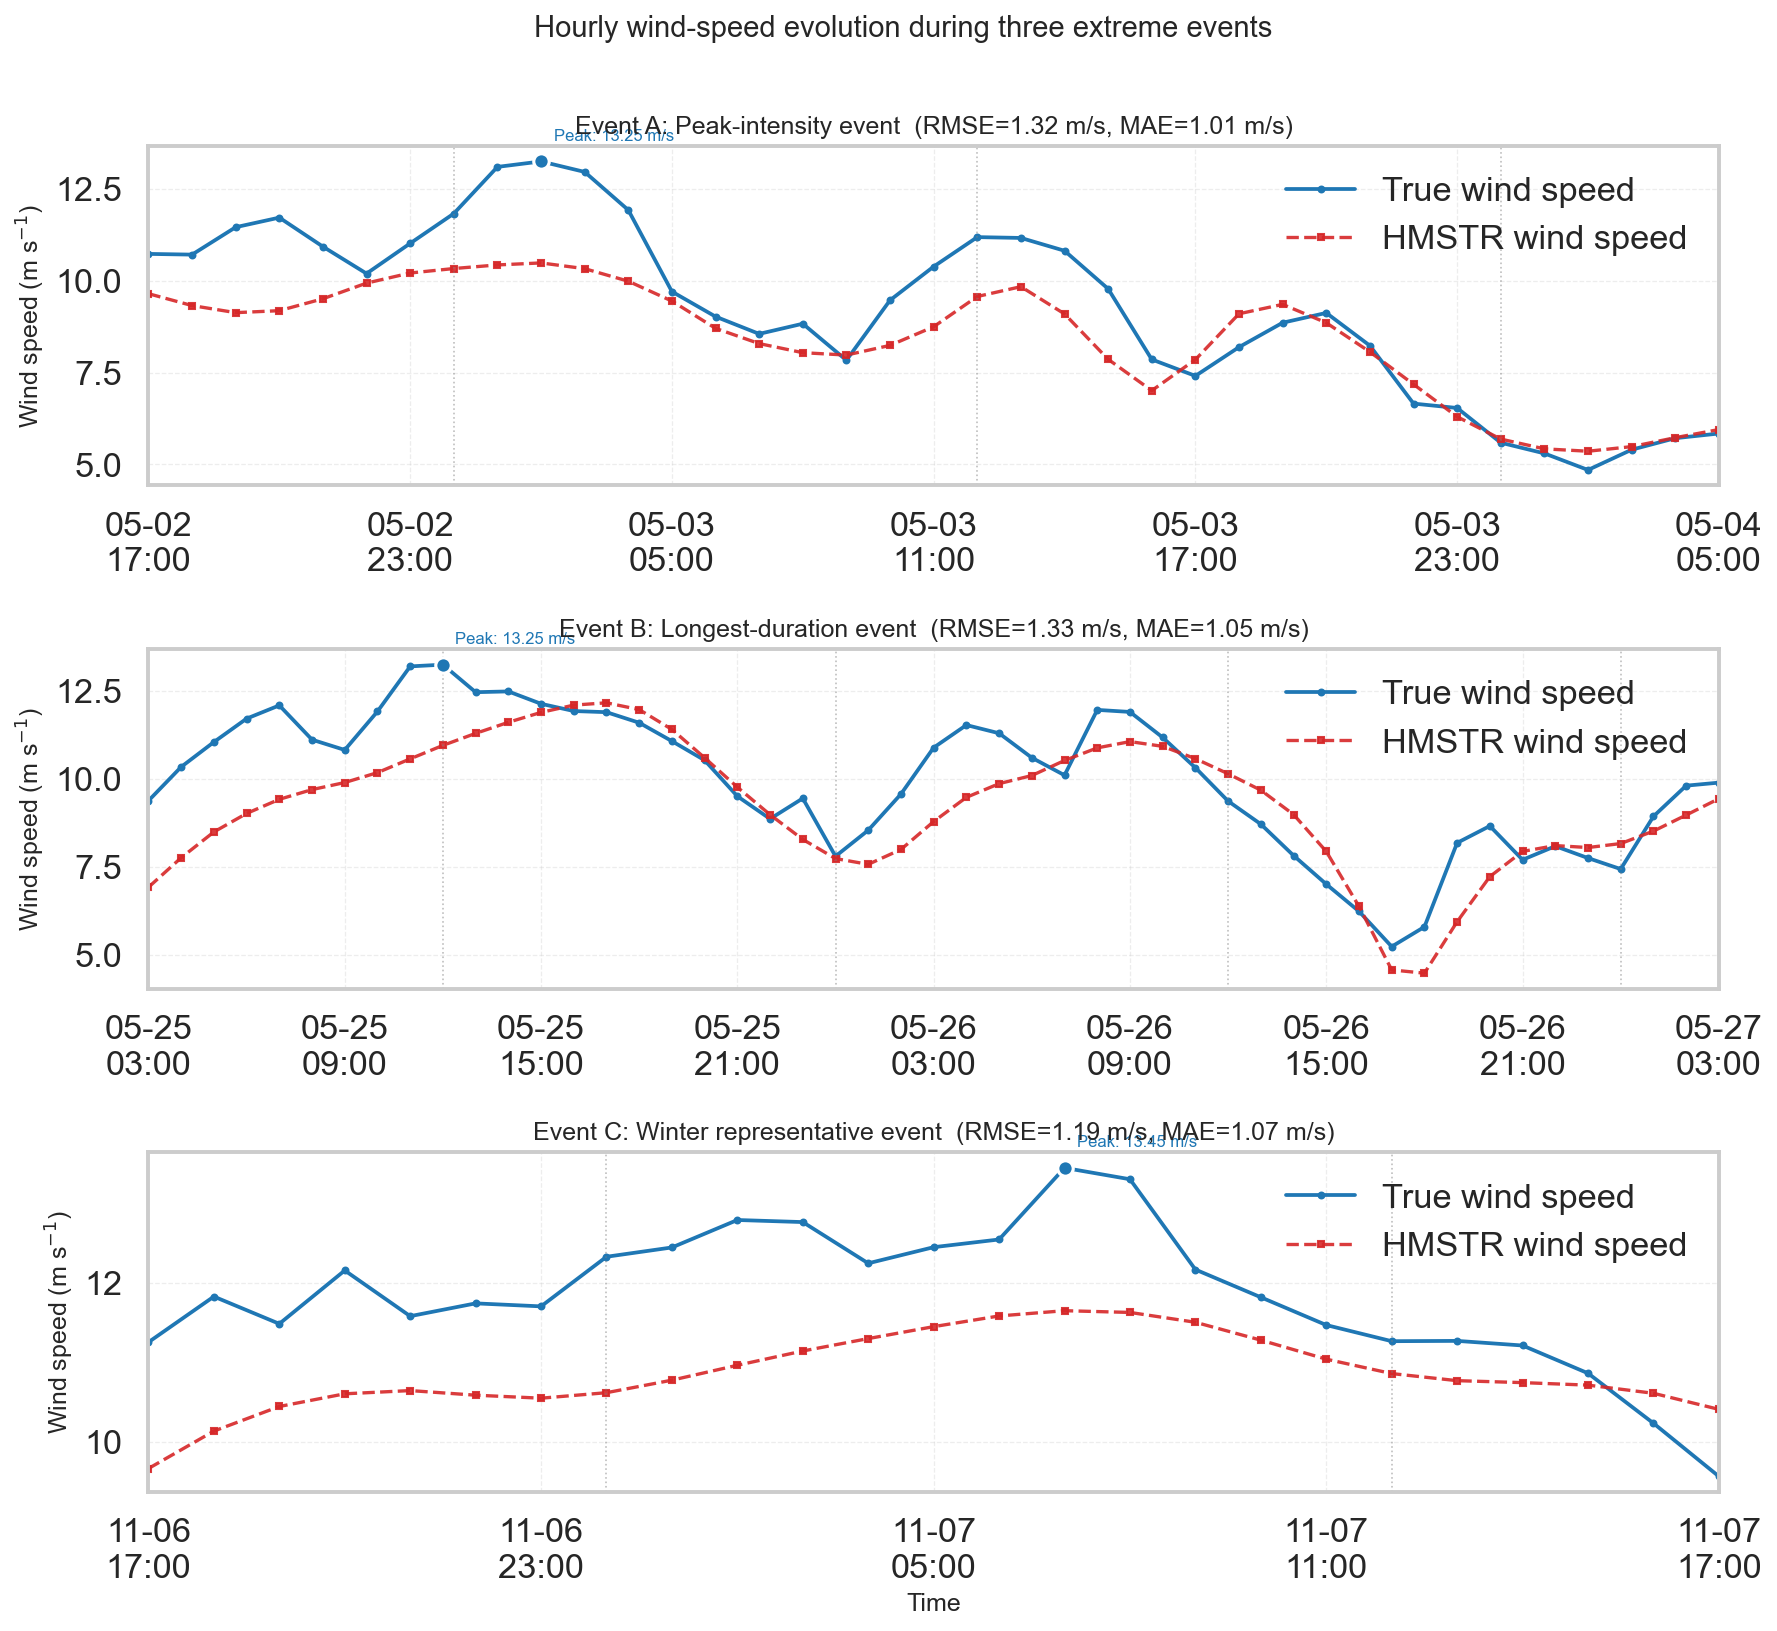

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd


# =====================================================
# 1. 读取数据并计算风速
# =====================================================
speed_data = np.load("../output/vst-conv_test.npz")

true = speed_data["true"]
pred = speed_data["pred"]

start_idx = 1757
true = true[start_idx:]
pred = pred[start_idx:]


# 数据维度：[sample, lead_time, channel, height, width]
y_true_u = true[:, :, 0, :, :]
y_true_v = true[:, :, 1, :, :]
y_pred_u = pred[:, :, 0, :, :]
y_pred_v = pred[:, :, 1, :, :]


def compute_wind_speed(u, v):
    """根据U、V风速分量计算风速大小。"""
    return np.sqrt(u**2 + v**2)


y_true = compute_wind_speed(y_true_u, y_true_v)
y_pred = compute_wind_speed(y_pred_u, y_pred_v)

num_samples = y_true.shape[0]

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)


# =====================================================
# 2. 预测和网格参数
# =====================================================
forecast_interval = 1     # 每12小时起报一次
use_lead_hours = 1        # 每次使用未来12小时结果

grid_row = 0
grid_col = 0

output_path = Path("../figures/wind_speed_timeseries.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

# 已知样本6821对应2023-05-02 17:00，据此反推首个样本时间
# 如果你已经知道测试集的准确起始时间，可以直接替换这一行
first_target_time = (
    pd.Timestamp("2023-01-01 00:00:00")
    - pd.Timedelta(hours=0)
)

print("First target time:", first_target_time)


# =====================================================
# 3. 构造每12小时起报一次的连续逐小时序列
# =====================================================
cycle_indices = np.arange(
    0,
    num_samples,
    forecast_interval
)

true_series = []
pred_series = []
time_list = []

for sample_idx in cycle_indices:

    # 当前样本实际可使用的预测长度
    available_hours = min(
        use_lead_hours,
        y_true.shape[1]
    )

    current_true = y_true[
        sample_idx,
        :available_hours,
        grid_row,
        grid_col
    ]

    current_pred = y_pred[
        sample_idx,
        :available_hours,
        grid_row,
        grid_col
    ]

    # 当前预测周期第一个目标时刻
    cycle_start_time = (
        first_target_time
        + pd.Timedelta(hours=int(sample_idx))
    )

    # 当前周期未来12小时对应的逐小时时刻
    current_times = pd.date_range(
        start=cycle_start_time,
        periods=available_hours,
        freq="h"
    )

    true_series.extend(current_true)
    pred_series.extend(current_pred)
    time_list.extend(current_times)


true_series = np.asarray(true_series)
pred_series = np.asarray(pred_series)
time_index = pd.DatetimeIndex(time_list)

print("True-series length:", len(true_series))
print("Pred-series length:", len(pred_series))
print("Time-index length:", len(time_index))
print("Time range:", time_index.min(), "to", time_index.max())

assert len(time_index) == len(true_series) == len(pred_series)


# =====================================================
# 4. 三个典型极端风速事件
# =====================================================
typical_events = [
    {
        "name": "Event_A",
        "title": "Event A: Peak-intensity event",
        "start_time": "2023-05-02 17:00:00",
        "end_time": "2023-05-04 05:00:00"
    },
    {
        "name": "Event_B",
        "title": "Event B: Longest-duration event",
        "start_time": "2023-05-25 03:00:00",
        "end_time": "2023-05-27 03:00:00"
    },
    {
        "name": "Event_C",
        "title": "Event C: Winter representative event",
        "start_time": "2023-11-06 17:00:00",
        "end_time": "2023-11-07 17:00:00"
    }
]


# =====================================================
# 5. 绘制三个事件的逐小时风速变化
# =====================================================
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 11),
    dpi=150
)

for ax, event in zip(axes, typical_events):

    start_time = pd.Timestamp(event["start_time"])
    end_time = pd.Timestamp(event["end_time"])

    # 按实际时间筛选事件
    event_mask = (
        (time_index >= start_time)
        & (time_index <= end_time)
    )

    event_time = time_index[event_mask]
    event_true = true_series[event_mask]
    event_pred = pred_series[event_mask]

    if len(event_time) == 0:
        ax.text(
            0.5,
            0.5,
            "No data in this time range",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        ax.set_title(event["title"])
        continue

    # 逐小时真实风速
    ax.plot(
        event_time,
        event_true,
        color="#1f77b4",
        linewidth=1.8,
        marker="o",
        markersize=2.8,
        label="True wind speed"
    )

    # 逐小时预测风速
    ax.plot(
        event_time,
        event_pred,
        color="#d62728",
        linewidth=1.6,
        linestyle="--",
        marker="s",
        markersize=2.5,
        alpha=0.9,
        label="HMSTR wind speed"
    )

    # 标记每12小时预测周期的分界
    cycle_boundary = start_time.ceil("12h")

    while cycle_boundary < end_time:
        ax.axvline(
            cycle_boundary,
            color="gray",
            linestyle=":",
            linewidth=0.8,
            alpha=0.5
        )
        cycle_boundary += pd.Timedelta(hours=12)

    # 计算当前事件误差
    rmse = np.sqrt(np.mean((event_pred - event_true) ** 2))
    mae = np.mean(np.abs(event_pred - event_true))

    # 标记真实风速峰值
    true_peak_idx = np.argmax(event_true)
    true_peak_time = event_time[true_peak_idx]
    true_peak_value = event_true[true_peak_idx]

    ax.scatter(
        true_peak_time,
        true_peak_value,
        color="#1f77b4",
        edgecolor="white",
        s=55,
        zorder=5
    )

    ax.annotate(
        f"Peak: {true_peak_value:.2f} m/s",
        xy=(true_peak_time, true_peak_value),
        xytext=(6, 10),
        textcoords="offset points",
        fontsize=8,
        color="#1f77b4"
    )

    ax.set_title(
        f'{event["title"]}  '
        f'(RMSE={rmse:.2f} m/s, MAE={mae:.2f} m/s)',
        fontsize=15
    )

    ax.set_ylabel(r"Wind speed (m s$^{-1}$)")
    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    ax.xaxis.set_major_locator(
        mdates.HourLocator(interval=6)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%m-%d\n%H:%M")
    )

    ax.legend(
        frameon=False,
        loc="upper right"
    )

    ax.margins(x=0)

axes[-1].set_xlabel("Time")

fig.suptitle(
    "Hourly wind-speed evolution during three extreme events",
    fontsize=14,
    y=0.995
)

fig.tight_layout()
fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()